# N05 — Adaptation Strategies and Trade-offs

This final notebook compares six methods after the N03 diagnosis:

1. frozen baseline;
2. mapping-only adaptation;
3. last-stage KL fine-tuning;
4. full KL fine-tuning;
5. concept-guided adaptation;
6. TENT.

NHANES Discovery is used for adaptation and checkpoint selection. NHANES Confirmation is protected until final evaluation. The result is reported as a target-performance, mechanism-repair, and source-retention trade-off.


## Reader Guide

**Pipeline role:** Compares the frozen baseline with five adaptation strategies after the failure mechanism has been diagnosed.

**Protection boundary:** NHANES Discovery supports adaptation and selection; NHANES Confirmation remains protected for final evaluation. **Produces:** per-method metrics, mechanism-repair analyses, bootstrap intervals, and a target-mechanism-source trade-off table.

**Reading route:** validate dependencies -> train methods on Discovery -> evaluate frozen and adapted ensembles -> quantify mechanism repair and source retention -> report the neutral trade-off.

## Primary outcomes

- NHANES Confirmation mapped-KL QWK.
- N03 shared-concept perception-gap reduction.
- OAI-test QWK retention.
- Shared-concept QWK and osteophyte grade-2 recall.
- MSR and concept-entropy AURC.

No method is required to dominate every outcome.


In [1]:



from dataclasses import asdict, dataclass

from datetime import datetime, timezone

from pathlib import Path

from time import perf_counter

from typing import Any



import hashlib

import importlib

import json

import random

import shutil

import subprocess

import sys

import uuid

import warnings










IN_COLAB = (

    "google.colab"

    in sys.modules

)



if IN_COLAB:

    from google.colab import drive



    drive.mount(

        "/content/drive",

        force_remount=False,

    )





MY_DRIVE = Path(

    "/content/drive/MyDrive"

)



if not MY_DRIVE.exists():

    raise RuntimeError(

        "Google Drive is not mounted. "

        "Expected /content/drive/MyDrive."

    )










def ensure_package(

    package: str,

    import_name: str | None = None,

) -> None:

    module_name = (

        import_name

        or package

    )



    try:

        importlib.import_module(

            module_name

        )



    except ImportError:

        subprocess.check_call([

            sys.executable,

            "-m",

            "pip",

            "install",

            "-q",

            package,

        ])





ensure_package(

    "timm"

)










import matplotlib.pyplot as plt

import numpy as np

import pandas as pd



from PIL import (

    Image,

    ImageOps,

)



from sklearn.metrics import (

    accuracy_score,

    cohen_kappa_score,

    f1_score,

    log_loss,

    mean_absolute_error,

)



import timm

import torch



from torch import nn

import torch.nn.functional as F



from torch.utils.data import (

    DataLoader,

    Dataset,

)



from torchvision import transforms



from tqdm.auto import tqdm










@dataclass(frozen=True)

class Config:

    backbone: str = (

        "convnext_tiny.fb_in1k"

    )



    image_size: int = 320



    batch_size_a100: int = 32

    batch_size_other_gpu: int = 16



    num_workers: int = 4

    cache_workers: int = 12



    validation_fraction: float = 0.20

    split_seed: int = 20260805



    supervised_epochs: int = 12

    tent_epochs: int = 3

    patience: int = 4



    mapping_lr: float = 3e-4

    head_lr: float = 1e-4

    last_stage_lr: float = 2e-5

    full_encoder_lr: float = 8e-6

    tent_lr: float = 1e-5



    weight_decay: float = 1e-4

    gradient_clip: float = 1.0



    direct_weight: float = 0.25

    concept_weight: float = 0.75

    distillation_weight: float = 0.50

    distillation_temperature: float = 2.0



    source_margin: float = 0.03

    source_penalty: float = 5.0



    bootstrap_repetitions: int = 2000

    bootstrap_seed: int = 20260806



    target_gain_margin: float = 0.02

    gap_reduction_margin: float = 0.02

    source_loss_margin: float = 0.03





CONFIG = Config()











PROJECT_ROOT = (

    MY_DRIVE

    / "Master Thesis"

)




FINAL_ROOT = (

    MY_DRIVE

    / "MasterThesis"

    / "Final Pipeline"

)





if not PROJECT_ROOT.exists():

    raise FileNotFoundError(

        "Original project root was not found:\n"

        f"{PROJECT_ROOT}"

    )



if not FINAL_ROOT.exists():

    raise FileNotFoundError(

        "Final Pipeline root was not found:\n"

        f"{FINAL_ROOT}"

    )










OAI_IMAGE_DIR = (

    PROJECT_ROOT

    / "oai"

    / "processed"

)



NHANES_IMAGE_DIR = (

    PROJECT_ROOT

    / "nhanes3"

    / "processed"

)





for directory_name, directory in (

    (

        "OAI processed-image directory",

        OAI_IMAGE_DIR,

    ),

    (

        "NHANES processed-image directory",

        NHANES_IMAGE_DIR,

    ),

):

    if not directory.exists():

        raise FileNotFoundError(

            f"{directory_name} was not found:\n"

            f"{directory}"

        )










DATA_DIR = (

    FINAL_ROOT

    / "data"

    / "N01"

)



N02A_CHECKPOINT_DIR = (

    FINAL_ROOT

    / "checkpoints"

    / "N02A"

)



N02A_MANIFEST_DIR = (

    FINAL_ROOT

    / "manifests"

    / "N02A"

)



N02A_TABLE_DIR = (

    FINAL_ROOT

    / "tables"

    / "N02A"

)



N02B_RESULT_DIR = (

    FINAL_ROOT

    / "results"

    / "N02B"

)



N02B_PREDICTION_DIR = (

    FINAL_ROOT

    / "predictions"

    / "N02B"

)



N03_RESULT_DIR = (

    FINAL_ROOT

    / "results"

    / "N03"

)



N03_TABLE_DIR = (

    FINAL_ROOT

    / "tables"

    / "N03"

)



N04_RESULT_DIR = (

    FINAL_ROOT

    / "results"

    / "N04"

)



N04_TABLE_DIR = (

    FINAL_ROOT

    / "tables"

    / "N04"

)










RESULT_DIR = (

    FINAL_ROOT

    / "results"

    / "N05"

)



TABLE_DIR = (

    FINAL_ROOT

    / "tables"

    / "N05"

)



FIGURE_DIR = (

    FINAL_ROOT

    / "figures"

    / "N05"

)



PREDICTION_DIR = (

    FINAL_ROOT

    / "predictions"

    / "N05"

)



CHECKPOINT_DIR = (

    FINAL_ROOT

    / "checkpoints"

    / "N05"

)



MANIFEST_DIR = (

    FINAL_ROOT

    / "manifests"

    / "N05"

)






LOCAL_IMAGE_DIR = Path(

    "/content/n05_images"

)





for folder in (

    RESULT_DIR,

    TABLE_DIR,

    FIGURE_DIR,

    PREDICTION_DIR,

    CHECKPOINT_DIR,

    MANIFEST_DIR,

    LOCAL_IMAGE_DIR,

):

    folder.mkdir(

        parents=True,

        exist_ok=True,

    )


















PROTOCOL = (

    "N05_ADAPTATION_COMPARISON"

)



NOTEBOOK_NAME = (

    "N05_Adaptation_Strategies.ipynb"

)



RUN_STARTED_UTC = datetime.now(

    timezone.utc

)



RUN_STARTED_TIMESTAMP = (

    RUN_STARTED_UTC.timestamp()

)










DEVICE = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)



if DEVICE.type != "cuda":

    raise RuntimeError(

        "N05 requires a GPU runtime."

    )





GPU_NAME = torch.cuda.get_device_name(

    0

)



BATCH_SIZE = (

    CONFIG.batch_size_a100

    if "A100" in GPU_NAME.upper()

    else CONFIG.batch_size_other_gpu

)



AMP_ENABLED = True

PIN_MEMORY = True





torch.backends.cudnn.benchmark = True



torch.set_float32_matmul_precision(

    "high"

)










METHODS = (

    "frozen",

    "mapping_only",

    "last_stage_kl",

    "full_kl",

    "concept_guided",

    "tent",

)



TRAINABLE_METHODS = (

    "mapping_only",

    "last_stage_kl",

    "full_kl",

    "concept_guided",

    "tent",

)



SHARED_CONCEPTS = (

    "osteophyte_max",

    "sclerosis_max",

)



ALL_CONCEPTS = (

    "osteophyte_max",

    "sclerosis_max",

    "jsn_max",

)










setup_paths = {

    "MyDrive":

        MY_DRIVE,



    "source project":

        PROJECT_ROOT,



    "Final Pipeline":

        FINAL_ROOT,



    "N01 data":

        DATA_DIR,



    "N02A checkpoints":

        N02A_CHECKPOINT_DIR,



    "N02A manifests":

        N02A_MANIFEST_DIR,



    "N02B predictions":

        N02B_PREDICTION_DIR,



    "N03 results":

        N03_RESULT_DIR,



    "N03 tables":

        N03_TABLE_DIR,



    "N04 results":

        N04_RESULT_DIR,



    "OAI images":

        OAI_IMAGE_DIR,



    "NHANES images":

        NHANES_IMAGE_DIR,

}





setup_audit_rows = []



for label, path in setup_paths.items():

    setup_audit_rows.append({

        "resource":

            label,



        "path":

            str(path),



        "exists":

            path.exists(),



        "is_directory":

            path.is_dir(),

    })





SETUP_AUDIT = pd.DataFrame(

    setup_audit_rows

)





missing_required_directories = (

    SETUP_AUDIT.loc[

        ~SETUP_AUDIT[

            "exists"

        ],

        [

            "resource",

            "path",

        ],

    ]

)



if len(

    missing_required_directories

) > 0:

    display(

        SETUP_AUDIT

    )



    raise FileNotFoundError(

        "One or more required N05 directories "

        "do not exist."

    )





display(

    SETUP_AUDIT

)





print()

print("=" * 78)

print("N05 SETUP")

print("=" * 78)



print(

    "GPU:",

    GPU_NAME,

)



print(

    "Device:",

    DEVICE,

)



print(

    "Batch size:",

    BATCH_SIZE,

)



print(

    "DataLoader workers:",

    CONFIG.num_workers,

)



print(

    "Image-cache workers:",

    CONFIG.cache_workers,

)



print(

    "Source project:",

    PROJECT_ROOT,

)



print(

    "Final Pipeline:",

    FINAL_ROOT,

)



print(

    "OAI images:",

    OAI_IMAGE_DIR,

)



print(

    "NHANES images:",

    NHANES_IMAGE_DIR,

)



print(

    "Local cache:",

    LOCAL_IMAGE_DIR,

)



print(

    "Methods:",

    METHODS,

)



print(

    "SETUP STATUS: PASS"

)



print("=" * 78)

Mounted at /content/drive


,resource,path,exists,is_directory
0,MyDrive,/content/drive/MyDrive,True,True
1,source project,/content/drive/MyDrive/Master Thesis,True,True
2,Final Pipeline,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,True
3,N01 data,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,True
4,N02A checkpoints,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,True
5,N02A manifests,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,True
6,N02B predictions,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,True
7,N03 results,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,True
8,N03 tables,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,True
9,N04 results,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,True



N05 SETUP
GPU: NVIDIA A100-SXM4-40GB
Device: cuda
Batch size: 32
DataLoader workers: 4
Image-cache workers: 12
Source project: /content/drive/MyDrive/Master Thesis
Final Pipeline: /content/drive/MyDrive/MasterThesis/Final Pipeline
OAI images: /content/drive/MyDrive/Master Thesis/oai/processed
NHANES images: /content/drive/MyDrive/Master Thesis/nhanes3/processed
Local cache: /content/n05_images
Methods: ('frozen', 'mapping_only', 'last_stage_kl', 'full_kl', 'concept_guided', 'tent')
SETUP STATUS: PASS


In [2]:



def set_seed(seed: int) -> None:

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)





def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:

    digest = hashlib.sha256()

    with path.open("rb") as handle:

        for block in iter(lambda: handle.read(chunk_size), b""):

            digest.update(block)

    return digest.hexdigest()





def atomic_csv(frame: pd.DataFrame, path: Path) -> None:

    path.parent.mkdir(parents=True, exist_ok=True)

    temporary = path.with_suffix(path.suffix + ".tmp")

    frame.to_csv(temporary, index=False)

    temporary.replace(path)





def atomic_json(payload: dict[str, Any], path: Path) -> None:

    path.parent.mkdir(parents=True, exist_ok=True)

    temporary = path.with_suffix(path.suffix + ".tmp")

    temporary.write_text(

        json.dumps(payload, indent=2),

        encoding="utf-8",

    )

    temporary.replace(path)





def robust_torch_load(source: Path) -> dict[str, Any]:

    if not source.exists() or source.stat().st_size == 0:

        raise FileNotFoundError(f"Missing checkpoint: {source}")

    staging = Path("/content/n05_checkpoint_staging")

    staging.mkdir(parents=True, exist_ok=True)

    local = staging / f"{source.name}.{uuid.uuid4().hex}.pt"

    try:

        shutil.copyfile(source, local)

        return torch.load(

            local,

            map_location="cpu",

            weights_only=False,

        )

    finally:

        local.unlink(missing_ok=True)





def robust_torch_save(payload: dict[str, Any], destination: Path) -> None:

    local = Path("/content") / (

        destination.name + "." + uuid.uuid4().hex + ".tmp"

    )

    torch.save(payload, local)

    shutil.copyfile(local, destination)

    local.unlink(missing_ok=True)





def normalize_rows(values: np.ndarray) -> np.ndarray:

    values = np.asarray(values, dtype=np.float64)

    if values.ndim != 2 or not np.isfinite(values).all():

        raise ValueError("Invalid probability matrix.")

    values = np.clip(values, 0.0, None)

    sums = values.sum(axis=1, keepdims=True)

    if (sums <= 0).any():

        raise ValueError("Probability row has zero mass.")

    return values / sums





def normalized_entropy(probabilities: np.ndarray) -> np.ndarray:

    probabilities = normalize_rows(probabilities)

    values = np.clip(probabilities, 1e-12, 1.0)

    return (

        -np.sum(values * np.log(values), axis=1)

        / np.log(probabilities.shape[1])

    )





def grouped_aurc(errors: np.ndarray, scores: np.ndarray) -> float:

    errors = np.asarray(errors, dtype=float)

    scores = np.asarray(scores, dtype=float)

    order = np.argsort(scores, kind="mergesort")

    errors = errors[order]

    scores = scores[order]

    _, counts = np.unique(scores, return_counts=True)



    coverage = [0.0]

    risk = [0.0]

    start = 0

    retained = 0

    cumulative_error = 0.0



    for count in counts:

        stop = start + int(count)

        retained += int(count)

        cumulative_error += float(errors[start:stop].sum())

        coverage.append(retained / len(errors))

        risk.append(cumulative_error / retained)

        start = stop



    return float(np.trapz(np.asarray(risk), np.asarray(coverage)))





def qwk(truth: np.ndarray, prediction: np.ndarray, classes: int = 5) -> float:

    with warnings.catch_warnings():

        warnings.simplefilter("ignore")

        value = cohen_kappa_score(

            truth,

            prediction,

            labels=list(range(classes)),

            weights="quadratic",

        )

    return float(value)





def grade_metrics(truth: np.ndarray, probabilities: np.ndarray) -> dict[str, float]:

    probabilities = normalize_rows(probabilities)

    prediction = probabilities.argmax(axis=1)

    return {

        "qwk": qwk(truth, prediction, 5),

        "accuracy": float(accuracy_score(truth, prediction)),

        "macro_f1": float(

            f1_score(

                truth,

                prediction,

                labels=list(range(5)),

                average="macro",

                zero_division=0,

            )

        ),

        "mae": float(mean_absolute_error(truth, prediction)),

        "nll": float(

            log_loss(

                truth,

                probabilities,

                labels=list(range(5)),

            )

        ),

    }





def save_figure(figure, name: str) -> None:

    figure.savefig(

        FIGURE_DIR / f"{name}.png",

        dpi=300,

        bbox_inches="tight",

    )

    figure.savefig(

        FIGURE_DIR / f"{name}.pdf",

        bbox_inches="tight",

    )

    plt.show()

    plt.close(figure)


## 1. Dependency, cohort, and Discovery split gate

N03 and N04 must pass. Discovery is split patient-wise into adaptation train and validation. Confirmation is excluded from all training and selection.


In [3]:



OAI_PATH = (

    DATA_DIR

    / "oai_cohort.csv"

)



NHANES_PATH = (

    DATA_DIR

    / "nhanes_cohort.csv"

)



OAI_PREDICTION_PATH = (

    FINAL_ROOT

    / "predictions"

    / "N02B"

    / "oai_predictions.csv"

)



CHECKPOINT_MANIFEST_PATH = (

    N02A_MANIFEST_DIR

    / "checkpoint_manifest.csv"

)



N03_STATUS_PATH = (

    N03_RESULT_DIR

    / "status.json"

)



N04_STATUS_PATH = (

    N04_RESULT_DIR

    / "status.json"

)



N03_MAPPING_PATH = (

    N03_TABLE_DIR

    / "T02_mapping_tables.csv"

)





required_inputs = [

    OAI_PATH,

    NHANES_PATH,

    OAI_PREDICTION_PATH,

    CHECKPOINT_MANIFEST_PATH,

    N03_STATUS_PATH,

    N04_STATUS_PATH,

    N03_MAPPING_PATH,

]



missing_inputs = [

    path

    for path in required_inputs

    if (

        not path.exists()

        or path.stat().st_size == 0

    )

]



if missing_inputs:

    raise FileNotFoundError(

        "Missing N05 inputs:\n"

        + "\n".join(

            f" - {path}"

            for path in missing_inputs

        )

    )










N03_STATUS = json.loads(

    N03_STATUS_PATH.read_text(

        encoding="utf-8"

    )

)



N04_STATUS = json.loads(

    N04_STATUS_PATH.read_text(

        encoding="utf-8"

    )

)



if not N03_STATUS.get(

    "passed",

    False,

):

    raise RuntimeError(

        "N03 did not pass."

    )



if not N04_STATUS.get(

    "passed",

    False,

):

    raise RuntimeError(

        "N04 did not pass."

    )










OAI = pd.read_csv(

    OAI_PATH,

    low_memory=False,

)



NHANES = pd.read_csv(

    NHANES_PATH,

    low_memory=False,

)



OAI_PREDICTIONS = pd.read_csv(

    OAI_PREDICTION_PATH,

    low_memory=False,

)



CHECKPOINT_MANIFEST = pd.read_csv(

    CHECKPOINT_MANIFEST_PATH,

    low_memory=False,

)



N03_MAPPING_EXPORT = pd.read_csv(

    N03_MAPPING_PATH,

    low_memory=False,

)










required_oai_columns = {

    "knee_key",

    "patient_id",

    "filename",

    "kl_grade",

    "osteophyte_max",

    "sclerosis_max",

    "jsn_max",

}



required_nhanes_columns = {

    "knee_key",

    "patient_id",

    "filename",

    "kl_grade",

    "osteophyte_max",

    "sclerosis_max",

    "analysis_subset",

}



required_oai_prediction_columns = {

    "knee_key",

    "model_split",

}



missing_oai_columns = (

    required_oai_columns

    - set(OAI.columns)

)



missing_nhanes_columns = (

    required_nhanes_columns

    - set(NHANES.columns)

)



missing_oai_prediction_columns = (

    required_oai_prediction_columns

    - set(OAI_PREDICTIONS.columns)

)



if missing_oai_columns:

    raise KeyError(

        "OAI cohort is missing columns: "

        f"{sorted(missing_oai_columns)}"

    )



if missing_nhanes_columns:

    raise KeyError(

        "NHANES cohort is missing columns: "

        f"{sorted(missing_nhanes_columns)}"

    )



if missing_oai_prediction_columns:

    raise KeyError(

        "N02B OAI predictions are missing columns: "

        f"{sorted(missing_oai_prediction_columns)}"

    )










for name, frame in (

    ("OAI cohort", OAI),

    ("NHANES cohort", NHANES),

    (

        "N02B OAI predictions",

        OAI_PREDICTIONS,

    ),

):

    if not frame[

        "knee_key"

    ].is_unique:

        raise RuntimeError(

            f"{name} knee_key is not unique."

        )






OAI[

    "knee_key"

] = OAI[

    "knee_key"

].astype(str)



NHANES[

    "knee_key"

] = NHANES[

    "knee_key"

].astype(str)



OAI_PREDICTIONS[

    "knee_key"

] = OAI_PREDICTIONS[

    "knee_key"

].astype(str)





oai_cohort_keys = set(

    OAI[

        "knee_key"

    ]

)



oai_prediction_keys = set(

    OAI_PREDICTIONS[

        "knee_key"

    ]

)



if oai_cohort_keys != oai_prediction_keys:

    missing_from_predictions = (

        oai_cohort_keys

        - oai_prediction_keys

    )



    extra_in_predictions = (

        oai_prediction_keys

        - oai_cohort_keys

    )



    raise RuntimeError(

        "OAI cohort and N02B predictions contain different knees.\n"

        f"Missing from predictions: {len(missing_from_predictions)}\n"

        f"Extra in predictions: {len(extra_in_predictions)}"

    )










split_lookup = (

    OAI_PREDICTIONS[

        [

            "knee_key",

            "model_split",

        ]

    ]

    .copy()

)



split_lookup[

    "model_split"

] = (

    split_lookup[

        "model_split"

    ]

    .astype(str)

    .str.strip()

    .str.lower()

)



expected_oai_splits = {

    "train",

    "validation",

    "test",

}



observed_oai_splits = set(

    split_lookup[

        "model_split"

    ].unique()

)



if observed_oai_splits != expected_oai_splits:

    raise RuntimeError(

        "Unexpected frozen OAI split labels.\n"

        f"Expected: {sorted(expected_oai_splits)}\n"

        f"Observed: {sorted(observed_oai_splits)}"

    )






if "model_split" in OAI.columns:

    OAI = OAI.drop(

        columns=[

            "model_split",

        ]

    )





OAI = OAI.merge(

    split_lookup,

    on="knee_key",

    how="left",

    validate="one_to_one",

)



if OAI[

    "model_split"

].isna().any():

    raise RuntimeError(

        "The OAI split merge produced missing assignments."

    )





atomic_csv(

    split_lookup,

    MANIFEST_DIR

    / "oai_split_assignments.csv",

)










for frame in (

    OAI,

    NHANES,

):

    frame[

        "patient_id"

    ] = frame[

        "patient_id"

    ].astype(str)










OAI_VALIDATION = (

    OAI.loc[

        OAI[

            "model_split"

        ].eq(

            "validation"

        )

    ]

    .copy()

    .reset_index(drop=True)

)



OAI_TEST = (

    OAI.loc[

        OAI[

            "model_split"

        ].eq(

            "test"

        )

    ]

    .copy()

    .reset_index(drop=True)

)










nhanes_subset_values = (

    NHANES[

        "analysis_subset"

    ]

    .astype(str)

    .str.strip()

    .str.lower()

)



expected_nhanes_subsets = {

    "discovery",

    "confirmation",

}



observed_nhanes_subsets = set(

    nhanes_subset_values.unique()

)



if observed_nhanes_subsets != expected_nhanes_subsets:

    raise RuntimeError(

        "Unexpected frozen NHANES subset labels.\n"

        f"Expected: {sorted(expected_nhanes_subsets)}\n"

        f"Observed: {sorted(observed_nhanes_subsets)}"

    )





NHANES_DISCOVERY = (

    NHANES.loc[

        nhanes_subset_values.eq(

            "discovery"

        )

    ]

    .copy()

    .reset_index(drop=True)

)



NHANES_CONFIRMATION = (

    NHANES.loc[

        nhanes_subset_values.eq(

            "confirmation"

        )

    ]

    .copy()

    .reset_index(drop=True)

)





for name, frame in (

    (

        "OAI validation",

        OAI_VALIDATION,

    ),

    (

        "OAI test",

        OAI_TEST,

    ),

    (

        "NHANES Discovery",

        NHANES_DISCOVERY,

    ),

    (

        "NHANES Confirmation",

        NHANES_CONFIRMATION,

    ),

):

    if len(frame) == 0:

        raise RuntimeError(

            f"{name} is empty."

        )










patients = np.asarray(

    sorted(

        NHANES_DISCOVERY[

            "patient_id"

        ].unique()

    )

)



rng = np.random.default_rng(

    CONFIG.split_seed

)



rng.shuffle(

    patients

)



validation_count = max(

    1,

    int(

        round(

            len(patients)

            * CONFIG.validation_fraction

        )

    ),

)



if validation_count >= len(patients):

    raise RuntimeError(

        "Discovery validation split would leave no training patients."

    )



validation_patients = set(

    patients[

        :validation_count

    ]

)



train_patients = set(

    patients[

        validation_count:

    ]

)





ADAPTATION_TRAIN = (

    NHANES_DISCOVERY.loc[

        NHANES_DISCOVERY[

            "patient_id"

        ].isin(

            train_patients

        )

    ]

    .copy()

    .reset_index(drop=True)

)



ADAPTATION_VALIDATION = (

    NHANES_DISCOVERY.loc[

        NHANES_DISCOVERY[

            "patient_id"

        ].isin(

            validation_patients

        )

    ]

    .copy()

    .reset_index(drop=True)

)





if len(ADAPTATION_TRAIN) == 0:

    raise RuntimeError(

        "NHANES Discovery adaptation train is empty."

    )



if len(ADAPTATION_VALIDATION) == 0:

    raise RuntimeError(

        "NHANES Discovery adaptation validation is empty."

    )



if (

    train_patients

    & validation_patients

):

    raise RuntimeError(

        "Discovery train and validation patients overlap."

    )





discovery_patient_set = set(

    NHANES_DISCOVERY[

        "patient_id"

    ]

)



confirmation_patient_set = set(

    NHANES_CONFIRMATION[

        "patient_id"

    ]

)



if (

    discovery_patient_set

    & confirmation_patient_set

):

    raise RuntimeError(

        "NHANES Discovery and Confirmation patients overlap."

    )










split_table = pd.DataFrame({

    "patient_id":

        patients,



    "adaptation_split": [

        (

            "validation"

            if patient

            in validation_patients

            else "train"

        )

        for patient in patients

    ],

})



atomic_csv(

    split_table,

    MANIFEST_DIR

    / "discovery_split.csv",

)










cohort_summary = pd.DataFrame([

    {

        "subset":

            "OAI validation",



        "patients":

            OAI_VALIDATION[

                "patient_id"

            ].nunique(),



        "knees":

            len(

                OAI_VALIDATION

            ),

    },

    {

        "subset":

            "OAI test",



        "patients":

            OAI_TEST[

                "patient_id"

            ].nunique(),



        "knees":

            len(

                OAI_TEST

            ),

    },

    {

        "subset":

            "NHANES Discovery train",



        "patients":

            ADAPTATION_TRAIN[

                "patient_id"

            ].nunique(),



        "knees":

            len(

                ADAPTATION_TRAIN

            ),

    },

    {

        "subset":

            "NHANES Discovery validation",



        "patients":

            ADAPTATION_VALIDATION[

                "patient_id"

            ].nunique(),



        "knees":

            len(

                ADAPTATION_VALIDATION

            ),

    },

    {

        "subset":

            "NHANES Confirmation",



        "patients":

            NHANES_CONFIRMATION[

                "patient_id"

            ].nunique(),



        "knees":

            len(

                NHANES_CONFIRMATION

            ),

    },

])



atomic_csv(

    cohort_summary,

    TABLE_DIR

    / "T01_cohort_summary.csv",

)





display(

    cohort_summary

)



print(

    "OAI split source:",

    OAI_PREDICTION_PATH,

)



print(

    "OAI split labels:",

    sorted(

        observed_oai_splits

    ),

)



print(

    "NHANES subset labels:",

    sorted(

        observed_nhanes_subsets

    ),

)



print(

    "Dependency and split gate: PASS"

)

,subset,patients,knees
0,OAI validation,530,1052
1,OAI test,530,1050
2,NHANES Discovery train,964,1909
3,NHANES Discovery validation,241,480
4,NHANES Confirmation,1205,2392


OAI split source: /content/drive/MyDrive/MasterThesis/Final Pipeline/predictions/N02B/oai_predictions.csv
OAI split labels: ['test', 'train', 'validation']
NHANES subset labels: ['confirmation', 'discovery']
Dependency and split gate: PASS


## 2. Image paths and local cache

Existing paths are used first. Unresolved images are found by exact basename under known roots, then copied to local Colab storage.


In [4]:



from concurrent.futures import (

    ThreadPoolExecutor,

    as_completed,

)





OAI_IMAGE_DIR = (

    PROJECT_ROOT

    / "oai"

    / "processed"

)



NHANES_IMAGE_DIR = (

    PROJECT_ROOT

    / "nhanes3"

    / "processed"

)



for name, directory in (

    (

        "OAI image directory",

        OAI_IMAGE_DIR,

    ),

    (

        "NHANES image directory",

        NHANES_IMAGE_DIR,

    ),

):

    if not directory.exists():

        raise FileNotFoundError(

            f"{name} is missing: {directory}"

        )





def resolve_exact_paths(

    frame: pd.DataFrame,

    image_directory: Path,

    cohort: str,

) -> pd.DataFrame:

    """

    Resolve images using the exact N01 source directory.



    No recursive Google Drive search is performed.

    """

    output = (

        frame

        .copy()

        .reset_index(drop=True)

    )



    resolved_paths = []



    for row in output.itertuples(

        index=False

    ):

        filename = str(

            row.filename

        )



        filename_path = Path(

            filename

        )



        candidates = []




        for column in (

            "image_path",

            "path",

        ):

            if not hasattr(

                row,

                column

            ):

                continue



            value = getattr(

                row,

                column

            )



            if pd.isna(value):

                continue



            candidates.append(

                Path(

                    str(value)

                )

            )




        candidates.append(

            image_directory

            / filename_path

        )




        candidates.append(

            image_directory

            / filename_path.name

        )



        selected_path = None



        for candidate in candidates:

            if (

                candidate.exists()

                and candidate.is_file()

                and candidate.stat().st_size > 0

            ):

                selected_path = (

                    candidate.resolve()

                )



                break



        resolved_paths.append(

            selected_path

        )



    missing_positions = [

        position

        for position, path in enumerate(

            resolved_paths

        )

        if path is None

    ]



    if missing_positions:

        examples = output.iloc[

            missing_positions[:10]

        ][

            [

                "knee_key",

                "filename",

            ]

        ]



        raise FileNotFoundError(

            f"{cohort}: {len(missing_positions)} images "

            "were not found under the exact N01 directory:\n"

            f"{image_directory}\n\n"

            f"{examples.to_string(index=False)}"

        )



    output[

        "source_image_path"

    ] = [

        str(path)

        for path in resolved_paths

    ]



    return output





def safe_cache_name(

    cohort: str,

    knee_key: str,

    source: Path,

) -> str:

    safe_key = (

        str(knee_key)

        .replace("/", "_")

        .replace("\\", "_")

        .replace(":", "_")

        .replace(" ", "_")

    )



    return (

        f"{cohort}_"

        f"{safe_key}"

        f"{source.suffix.lower()}"

    )





def cache_one_image(

    row,

) -> dict[str, str]:

    source = Path(

        row.source_image_path

    )



    destination = (

        LOCAL_IMAGE_DIR

        / str(row.cohort)

        / safe_cache_name(

            str(row.cohort),

            str(row.knee_key),

            source,

        )

    )



    destination.parent.mkdir(

        parents=True,

        exist_ok=True,

    )



    if (

        destination.exists()

        and destination.is_file()

        and destination.stat().st_size

        == source.stat().st_size

    ):

        return {

            "knee_key":

                str(row.knee_key),



            "image_path":

                str(destination),



            "cache_status":

                "cached",

        }



    temporary = destination.with_suffix(

        destination.suffix + ".tmp"

    )



    temporary.unlink(

        missing_ok=True

    )



    shutil.copyfile(

        source,

        temporary,

    )



    if (

        not temporary.exists()

        or temporary.stat().st_size

        != source.stat().st_size

    ):

        temporary.unlink(

            missing_ok=True

        )



        raise RuntimeError(

            "Local copy verification failed:\n"

            f"{source}"

        )



    temporary.replace(

        destination

    )



    return {

        "knee_key":

            str(row.knee_key),



        "image_path":

            str(destination),



        "cache_status":

            "copied",

    }










OAI_REQUIRED = (

    pd.concat(

        [

            OAI_VALIDATION,

            OAI_TEST,

        ],

        ignore_index=True,

    )

    .drop_duplicates(

        subset=[

            "knee_key",

        ]

    )

    .reset_index(drop=True)

)



NHANES_REQUIRED = (

    pd.concat(

        [

            ADAPTATION_TRAIN,

            ADAPTATION_VALIDATION,

            NHANES_CONFIRMATION,

        ],

        ignore_index=True,

    )

    .drop_duplicates(

        subset=[

            "knee_key",

        ]

    )

    .reset_index(drop=True)

)





OAI_REQUIRED = resolve_exact_paths(

    OAI_REQUIRED,

    OAI_IMAGE_DIR,

    "OAI",

)



NHANES_REQUIRED = resolve_exact_paths(

    NHANES_REQUIRED,

    NHANES_IMAGE_DIR,

    "NHANES",

)





required_images = pd.concat(

    [

        OAI_REQUIRED.assign(

            cohort="OAI"

        ),



        NHANES_REQUIRED.assign(

            cohort="NHANES"

        ),

    ],

    ignore_index=True,

)





if not required_images[

    "knee_key"

].astype(str).is_unique:

    duplicate_keys = (

        required_images.loc[

            required_images[

                "knee_key"

            ]

            .astype(str)

            .duplicated(

                keep=False

            ),

            [

                "cohort",

                "knee_key",

                "filename",

            ],

        ]

    )



    display(

        duplicate_keys

    )



    raise RuntimeError(

        "Required image knee_key values are not unique."

    )





LOCAL_IMAGE_DIR.mkdir(

    parents=True,

    exist_ok=True,

)










rows = list(

    required_images.itertuples(

        index=False

    )

)



cache_results = []



with ThreadPoolExecutor(

    max_workers=12

) as executor:

    futures = {

        executor.submit(

            cache_one_image,

            row,

        ): row

        for row in rows

    }



    for future in tqdm(

        as_completed(

            futures

        ),

        total=len(

            futures

        ),

        desc="Caching images",

        unit="image",

    ):

        try:

            cache_results.append(

                future.result()

            )



        except Exception as error:

            failed_row = futures[

                future

            ]



            raise RuntimeError(

                "Image caching failed for:\n"

                f"cohort={failed_row.cohort}\n"

                f"knee_key={failed_row.knee_key}\n"

                f"source={failed_row.source_image_path}"

            ) from error





cache_table = pd.DataFrame(

    cache_results

)



if len(cache_table) != len(

    required_images

):

    raise RuntimeError(

        "The number of cached images does not match "

        "the required image count."

    )



if not cache_table[

    "knee_key"

].is_unique:

    raise RuntimeError(

        "Cached image knee_key values are not unique."

    )





required_images[

    "knee_key"

] = required_images[

    "knee_key"

].astype(str)



cache_table[

    "knee_key"

] = cache_table[

    "knee_key"

].astype(str)





required_images = required_images.merge(

    cache_table,

    on="knee_key",

    how="left",

    validate="one_to_one",

)





if required_images[

    "image_path"

].isna().any():

    raise RuntimeError(

        "At least one local image path is missing."

    )






invalid_local_files = []



for row in required_images.itertuples(

    index=False

):

    local_path = Path(

        row.image_path

    )



    source_path = Path(

        row.source_image_path

    )



    if (

        not local_path.exists()

        or not local_path.is_file()

        or local_path.stat().st_size

        != source_path.stat().st_size

    ):

        invalid_local_files.append({

            "knee_key":

                str(row.knee_key),



            "source":

                str(source_path),



            "local":

                str(local_path),

        })





if invalid_local_files:

    display(

        pd.DataFrame(

            invalid_local_files

        ).head(20)

    )



    raise RuntimeError(

        f"{len(invalid_local_files)} local image files "

        "failed verification."

    )










path_map = dict(

    zip(

        required_images[

            "knee_key"

        ],

        required_images[

            "image_path"

        ],

    )

)





for frame_name, frame in (

    (

        "OAI validation",

        OAI_VALIDATION,

    ),

    (

        "OAI test",

        OAI_TEST,

    ),

    (

        "NHANES Discovery train",

        ADAPTATION_TRAIN,

    ),

    (

        "NHANES Discovery validation",

        ADAPTATION_VALIDATION,

    ),

    (

        "NHANES Confirmation",

        NHANES_CONFIRMATION,

    ),

):

    frame[

        "image_path"

    ] = (

        frame[

            "knee_key"

        ]

        .astype(str)

        .map(

            path_map

        )

    )



    missing_local_paths = frame[

        "image_path"

    ].isna()



    if missing_local_paths.any():

        examples = frame.loc[

            missing_local_paths,

            [

                "knee_key",

                "filename",

            ],

        ].head(10)



        raise RuntimeError(

            f"{frame_name}: local image path assignment failed.\n"

            f"{examples.to_string(index=False)}"

        )










image_path_audit = required_images[

    [

        "cohort",

        "knee_key",

        "filename",

        "source_image_path",

        "image_path",

        "cache_status",

    ]

].copy()





atomic_csv(

    image_path_audit,

    TABLE_DIR

    / "T02_image_path_audit.csv",

)





cache_summary = (

    image_path_audit[

        "cache_status"

    ]

    .value_counts()

    .rename_axis(

        "cache_status"

    )

    .reset_index(

        name="images"

    )

)



display(

    cache_summary

)





print(

    "OAI image directory:",

    OAI_IMAGE_DIR,

)



print(

    "NHANES image directory:",

    NHANES_IMAGE_DIR,

)



print(

    "Required images:",

    len(

        required_images

    ),

)



print(

    "Verified local images:",

    len(

        required_images

    ),

)



print(

    "Image cache gate: PASS"

)

Caching images:   0%|          | 0/6883 [00:00<?, ?image/s]

,cache_status,images
0,copied,6883


OAI image directory: /content/drive/MyDrive/Master Thesis/oai/processed
NHANES image directory: /content/drive/MyDrive/Master Thesis/nhanes3/processed
Required images: 6883
Verified local images: 6883
Image cache gate: PASS


## 3. Data pipeline and exact model architecture


In [5]:



IMAGENET_MEAN = (0.485, 0.456, 0.406)

IMAGENET_STD = (0.229, 0.224, 0.225)



training_transform = transforms.Compose([

    transforms.Grayscale(num_output_channels=3),

    transforms.Resize(

        (CONFIG.image_size + 24, CONFIG.image_size + 24)

    ),

    transforms.RandomCrop(CONFIG.image_size),

    transforms.RandomAffine(

        degrees=4,

        translate=(0.02, 0.02),

        scale=(0.98, 1.02),

    ),

    transforms.ColorJitter(brightness=0.06, contrast=0.08),

    transforms.ToTensor(),

    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),

])



evaluation_transform = transforms.Compose([

    transforms.Grayscale(num_output_channels=3),

    transforms.Resize((CONFIG.image_size, CONFIG.image_size)),

    transforms.ToTensor(),

    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),

])





class KneeDataset(Dataset):

    def __init__(self, frame: pd.DataFrame, transform):

        self.frame = frame.reset_index(drop=True).copy()

        self.transform = transform



    def __len__(self) -> int:

        return len(self.frame)



    def __getitem__(self, index: int) -> dict[str, Any]:

        row = self.frame.iloc[index]

        with Image.open(Path(row["image_path"])) as image:

            image = ImageOps.exif_transpose(image).convert("L")

            image = self.transform(image)



        jsn_value = (

            int(row["jsn_max"])

            if "jsn_max" in row.index and pd.notna(row["jsn_max"])

            else -1

        )



        return {

            "image": image,

            "kl_grade": torch.tensor(

                int(row["kl_grade"]),

                dtype=torch.long,

            ),

            "osteophyte_max": torch.tensor(

                int(row["osteophyte_max"]),

                dtype=torch.long,

            ),

            "sclerosis_max": torch.tensor(

                int(row["sclerosis_max"]),

                dtype=torch.long,

            ),

            "jsn_max": torch.tensor(

                jsn_value,

                dtype=torch.long,

            ),

            "row_index": torch.tensor(index, dtype=torch.long),

        }





def make_loader(

    frame: pd.DataFrame,

    training: bool,

    seed: int,

) -> DataLoader:

    generator = torch.Generator()

    generator.manual_seed(seed)



    arguments = {

        "dataset": KneeDataset(

            frame,

            training_transform if training else evaluation_transform,

        ),

        "batch_size": BATCH_SIZE,

        "shuffle": training,

        "num_workers": CONFIG.num_workers,

        "pin_memory": PIN_MEMORY,

        "persistent_workers": CONFIG.num_workers > 0,

        "generator": generator,

    }

    if CONFIG.num_workers > 0:

        arguments["prefetch_factor"] = 2

    return DataLoader(**arguments)





class ConceptBottleneckNet(nn.Module):

    def __init__(self, backbone_name: str):

        super().__init__()

        self.encoder = timm.create_model(

            backbone_name,

            pretrained=False,

            num_classes=0,

            global_pool="avg",

            in_chans=3,

            drop_path_rate=0.10,

        )

        feature_dimension = self.encoder.num_features

        self.feature_dropout = nn.Dropout(0.20)

        self.concept_heads = nn.ModuleDict({

            concept: nn.Linear(feature_dimension, 4)

            for concept in ALL_CONCEPTS

        })

        self.concept_mapping = nn.Sequential(

            nn.Linear(12, 64),

            nn.LayerNorm(64),

            nn.GELU(),

            nn.Dropout(0.20),

            nn.Linear(64, 5),

        )

        self.direct_kl_head = nn.Linear(feature_dimension, 5)



    def forward(self, images: torch.Tensor) -> dict[str, Any]:

        features = self.feature_dropout(self.encoder(images))

        concept_logits = {

            concept: self.concept_heads[concept](features)

            for concept in ALL_CONCEPTS

        }

        concept_probabilities = torch.cat([

            torch.softmax(concept_logits[concept], dim=1)

            for concept in ALL_CONCEPTS

        ], dim=1)



        return {

            "features": features,

            "concept_logits": concept_logits,

            "mapped_kl_logits": self.concept_mapping(

                concept_probabilities

            ),

            "direct_kl_logits": self.direct_kl_head(features),

        }





print("Data pipeline and architecture: PASS")


Data pipeline and architecture: PASS


## 4. Frozen checkpoint gate


In [6]:



if len(CHECKPOINT_MANIFEST) != 3:

    raise RuntimeError("Exactly three frozen checkpoints are required.")



SOURCE_RECORDS = []



for row in (

    CHECKPOINT_MANIFEST

    .sort_values("seed")

    .itertuples(index=False)

):

    seed = int(row.seed)

    checkpoint_path = (

        N02A_CHECKPOINT_DIR

        / f"convnext_tiny_seed{seed}.pt"

    )

    observed_hash = sha256_file(checkpoint_path)



    if observed_hash != str(row.sha256):

        raise RuntimeError(

            f"Checkpoint hash mismatch for seed {seed}."

        )



    checkpoint = robust_torch_load(checkpoint_path)



    if int(checkpoint.get("seed", -1)) != seed:

        raise RuntimeError(

            f"Checkpoint seed mismatch for seed {seed}."

        )

    if checkpoint.get("requested_backbone") != CONFIG.backbone:

        raise RuntimeError(

            f"Backbone mismatch for seed {seed}."

        )



    SOURCE_RECORDS.append({

        "seed": seed,

        "source_path": str(checkpoint_path),

        "source_sha256": observed_hash,

        "source_state": checkpoint["model_state_dict"],

    })

    del checkpoint



checkpoint_gate = pd.DataFrame([

    {

        key: value

        for key, value in record.items()

        if key != "source_state"

    }

    for record in SOURCE_RECORDS

])

atomic_csv(checkpoint_gate, TABLE_DIR / "T03_checkpoint_gate.csv")

display(checkpoint_gate)

print("Checkpoint gate: PASS")


,seed,source_path,source_sha256
0,367761876,/content/drive/MyDrive/MasterThesis/Final Pipe...,28a3bc72f1f23b7116810b437fcc5e3d8e4cfa2035145f...
1,1023912954,/content/drive/MyDrive/MasterThesis/Final Pipe...,4de751563b6c30577fbd8d17152d3d1b5bd0865fa15948...
2,1767922150,/content/drive/MyDrive/MasterThesis/Final Pipe...,bab8fc6638449d4af918d68a6629a70893697e60962f64...


Checkpoint gate: PASS


## 5. Training and inference helpers


In [7]:



def configure_method(

    model: ConceptBottleneckNet,

    method: str,

) -> list[dict[str, Any]]:

    for parameter in model.parameters():

        parameter.requires_grad_(False)



    if method == "mapping_only":

        for parameter in model.concept_mapping.parameters():

            parameter.requires_grad_(True)

        return [{

            "params": list(model.concept_mapping.parameters()),

            "lr": CONFIG.mapping_lr,

        }]



    if method in ("last_stage_kl", "concept_guided"):

        for parameter in model.encoder.stages[-1].parameters():

            parameter.requires_grad_(True)

        for module in (

            model.concept_heads,

            model.concept_mapping,

            model.direct_kl_head,

        ):

            for parameter in module.parameters():

                parameter.requires_grad_(True)



        return [

            {

                "params": list(model.encoder.stages[-1].parameters()),

                "lr": CONFIG.last_stage_lr,

            },

            {

                "params": [

                    parameter

                    for module in (

                        model.concept_heads,

                        model.concept_mapping,

                        model.direct_kl_head,

                    )

                    for parameter in module.parameters()

                ],

                "lr": CONFIG.head_lr,

            },

        ]



    if method == "full_kl":

        for parameter in model.parameters():

            parameter.requires_grad_(True)

        return [

            {

                "params": list(model.encoder.parameters()),

                "lr": CONFIG.full_encoder_lr,

            },

            {

                "params": [

                    parameter

                    for module in (

                        model.concept_heads,

                        model.concept_mapping,

                        model.direct_kl_head,

                    )

                    for parameter in module.parameters()

                ],

                "lr": CONFIG.head_lr,

            },

        ]



    if method == "tent":

        trainable = []

        for module in model.modules():

            if isinstance(module, nn.LayerNorm):

                for parameter in module.parameters():

                    parameter.requires_grad_(True)

                    trainable.append(parameter)

        if not trainable:

            raise RuntimeError("TENT found no LayerNorm parameters.")

        return [{

            "params": trainable,

            "lr": CONFIG.tent_lr,

        }]



    raise ValueError(f"Unsupported method: {method}")





def distillation_loss(

    student_logits: torch.Tensor,

    teacher_logits: torch.Tensor,

) -> torch.Tensor:

    temperature = CONFIG.distillation_temperature

    return (

        F.kl_div(

            F.log_softmax(student_logits / temperature, dim=1),

            F.softmax(teacher_logits / temperature, dim=1),

            reduction="batchmean",

        )

        * temperature

        * temperature

    )





@torch.no_grad()

def predict_model(

    model: ConceptBottleneckNet,

    frame: pd.DataFrame,

    seed: int,

    offload_after: bool = False,

) -> dict[str, Any]:

    loader = make_loader(frame, training=False, seed=seed)



    model.to(DEVICE)

    model.to(memory_format=torch.channels_last)

    model.eval()



    mapped = []

    direct = []

    concepts = {concept: [] for concept in ALL_CONCEPTS}

    indices = []



    for batch in tqdm(loader, desc="Inference", leave=False):

        images = batch["image"].to(

            DEVICE,

            non_blocking=True,

            memory_format=torch.channels_last,

        )



        with torch.autocast(

            device_type="cuda",

            dtype=torch.float16,

            enabled=AMP_ENABLED,

        ):

            output = model(images)



        mapped.append(

            torch.softmax(

                output["mapped_kl_logits"],

                dim=1,

            ).float().cpu().numpy()

        )

        direct.append(

            torch.softmax(

                output["direct_kl_logits"],

                dim=1,

            ).float().cpu().numpy()

        )

        for concept in ALL_CONCEPTS:

            concepts[concept].append(

                torch.softmax(

                    output["concept_logits"][concept],

                    dim=1,

                ).float().cpu().numpy()

            )



        indices.extend(batch["row_index"].cpu().tolist())



    if indices != list(range(len(frame))):

        raise RuntimeError("Inference row order changed.")



    result = {

        "mapped_kl": normalize_rows(

            np.concatenate(mapped, axis=0)

        ),

        "direct_kl": normalize_rows(

            np.concatenate(direct, axis=0)

        ),

        "concepts": {

            concept: normalize_rows(

                np.concatenate(concepts[concept], axis=0)

            )

            for concept in ALL_CONCEPTS

        },

    }



    if offload_after:

        model.to("cpu")

        torch.cuda.empty_cache()



    return result





def ensemble_predict(

    records: list[dict[str, Any]],

    frame: pd.DataFrame,

) -> dict[str, Any]:

    outputs = [

        predict_model(

            record["model"],

            frame,

            seed=record["seed"] + 100_000,

            offload_after=True,

        )

        for record in records

    ]



    return {

        "mapped_kl": normalize_rows(

            np.mean(

                np.stack([

                    output["mapped_kl"]

                    for output in outputs

                ]),

                axis=0,

            )

        ),

        "direct_kl": normalize_rows(

            np.mean(

                np.stack([

                    output["direct_kl"]

                    for output in outputs

                ]),

                axis=0,

            )

        ),

        "concepts": {

            concept: normalize_rows(

                np.mean(

                    np.stack([

                        output["concepts"][concept]

                        for output in outputs

                    ]),

                    axis=0,

                )

            )

            for concept in ALL_CONCEPTS

        },

    }





def validation_qwk(

    model: ConceptBottleneckNet,

    frame: pd.DataFrame,

    seed: int,

) -> float:

    output = predict_model(model, frame, seed)

    return grade_metrics(

        frame["kl_grade"].to_numpy(dtype=int),

        output["mapped_kl"],

    )["qwk"]





print("Training and inference helpers: PASS")


Training and inference helpers: PASS


## 6. Train five adaptation methods

Supervised methods use Discovery train labels and Discovery validation for checkpoint selection. Concept-guided adaptation adds shared-concept supervision and source-logit distillation. TENT uses no labels and a fixed number of entropy-minimization epochs.


In [8]:











def make_loader(

    frame: pd.DataFrame,

    training: bool,

    seed: int,

) -> DataLoader:

    generator = torch.Generator()

    generator.manual_seed(

        int(seed)

    )



    dataset = KneeDataset(

        frame=frame,

        transform=(

            training_transform

            if training

            else evaluation_transform

        ),

    )



    return DataLoader(

        dataset,

        batch_size=BATCH_SIZE,

        shuffle=training,

        num_workers=0,

        pin_memory=PIN_MEMORY,

        persistent_workers=False,

        drop_last=False,

        generator=generator,

    )





def release_loader(

    loader: DataLoader | None,

) -> None:

    """

    Release a DataLoader without accessing private multiprocessing state.

    """

    if loader is None:

        return



    del loader





def set_tent_mode(

    model: ConceptBottleneckNet,

) -> None:

    """

    TENT updates only normalization affine parameters.



    The whole model stays in evaluation mode so dropout and other

    stochastic training behavior remain disabled.

    """

    model.eval()



    for module in model.modules():

        if isinstance(

            module,

            nn.LayerNorm,

        ):

            module.train()





PRIOR_HISTORY_PATH = (

    RESULT_DIR

    / "training_history.csv"

)



if (

    PRIOR_HISTORY_PATH.exists()

    and PRIOR_HISTORY_PATH.stat().st_size > 0

):

    PRIOR_TRAINING_HISTORY = pd.read_csv(

        PRIOR_HISTORY_PATH,

        low_memory=False,

    )

else:

    PRIOR_TRAINING_HISTORY = pd.DataFrame()





def legacy_training_completed(

    method: str,

    seed: int,

    best_epoch: int,

) -> bool:

    """Validate an older checkpoint using its saved epoch history."""

    if PRIOR_TRAINING_HISTORY.empty:

        return False



    required_columns = {

        "method",

        "seed",

        "epoch",

    }



    if not required_columns.issubset(

        PRIOR_TRAINING_HISTORY.columns

    ):

        return False



    rows = PRIOR_TRAINING_HISTORY.loc[

        PRIOR_TRAINING_HISTORY["method"].astype(str).eq(method)

        & pd.to_numeric(

            PRIOR_TRAINING_HISTORY["seed"],

            errors="coerce",

        ).eq(seed)

    ].copy()



    if rows.empty:

        return False



    completed_epoch = int(

        pd.to_numeric(

            rows["epoch"],

            errors="coerce",

        ).max()

    )



    if method == "tent":

        return completed_epoch >= CONFIG.tent_epochs



    reached_planned_end = (

        completed_epoch >= CONFIG.supervised_epochs

    )



    reached_early_stopping = (

        completed_epoch

        >= int(best_epoch) + CONFIG.patience

    )



    return bool(

        reached_planned_end

        or reached_early_stopping

    )





def checkpoint_is_usable(

    checkpoint_path: Path,

    method: str,

    seed: int,

    source_sha256: str,

) -> bool:

    """

    Return True only when an existing N05 checkpoint belongs to the

    current method, seed, source checkpoint, and configuration.

    """

    if (

        not checkpoint_path.exists()

        or checkpoint_path.stat().st_size == 0

    ):

        return False



    try:

        payload = robust_torch_load(

            checkpoint_path

        )



        metadata_valid = (

            payload.get("stage") == "N05"

            and payload.get("protocol") == PROTOCOL

            and payload.get("method") == method

            and int(

                payload.get(

                    "seed",

                    -1,

                )

            ) == int(seed)

            and payload.get(

                "source_sha256"

            ) == source_sha256

            and "model_state_dict" in payload

            and int(

                payload.get(

                    "epoch",

                    0,

                )

            ) >= 1

        )



        explicitly_complete = bool(

            payload.get(

                "training_complete",

                False,

            )

        )



        legacy_complete = legacy_training_completed(

            method=method,

            seed=int(seed),

            best_epoch=int(

                payload.get(

                    "epoch",

                    0,

                )

            ),

        )



        valid = bool(

            metadata_valid

            and (

                explicitly_complete

                or legacy_complete

            )

        )



        del payload



        return bool(valid)



    except Exception:

        return False





TRAINED_RECORDS = []

HISTORY_ROWS = []





for source_record in SOURCE_RECORDS:

    seed = int(

        source_record[

            "seed"

        ]

    )



    source_sha256 = str(

        source_record[

            "source_sha256"

        ]

    )



    set_seed(

        seed

    )








    baseline_model = ConceptBottleneckNet(

        CONFIG.backbone

    )



    baseline_model.load_state_dict(

        source_record[

            "source_state"

        ],

        strict=True,

    )



    baseline_model.eval()



    baseline_model.to(

        DEVICE

    )



    baseline_model.to(

        memory_format=torch.channels_last

    )



    baseline_oai_qwk = validation_qwk(

        baseline_model,

        OAI_VALIDATION,

        seed + 10_000,

    )



    baseline_model.to(

        "cpu"

    )



    del baseline_model



    torch.cuda.empty_cache()



    print()

    print("=" * 78)

    print(

        f"SOURCE SEED {seed}"

    )

    print(

        "Frozen OAI-validation QWK:",

        round(

            baseline_oai_qwk,

            4,

        ),

    )

    print("=" * 78)








    for method in TRAINABLE_METHODS:

        set_seed(

            seed

        )



        checkpoint_path = (

            CHECKPOINT_DIR

            / f"{method}_seed{seed}.pt"

        )








        if checkpoint_is_usable(

            checkpoint_path=checkpoint_path,

            method=method,

            seed=seed,

            source_sha256=source_sha256,

        ):

            saved_payload = robust_torch_load(

                checkpoint_path

            )



            if not saved_payload.get(

                "training_complete",

                False,

            ):

                saved_payload[

                    "training_complete"

                ] = True

                saved_payload[

                    "completion_source"

                ] = "validated_legacy_history"

                saved_payload[

                    "completed_utc"

                ] = datetime.now(

                    timezone.utc

                ).isoformat()



                robust_torch_save(

                    saved_payload,

                    checkpoint_path,

                )



            saved_model = ConceptBottleneckNet(

                CONFIG.backbone

            )



            saved_model.load_state_dict(

                saved_payload[

                    "model_state_dict"

                ],

                strict=True,

            )



            saved_model.eval()



            saved_model.to(

                "cpu"

            )



            TRAINED_RECORDS.append({

                "method":

                    method,



                "seed":

                    seed,



                "model":

                    saved_model,



                "checkpoint_path":

                    str(

                        checkpoint_path

                    ),



                "checkpoint_sha256":

                    sha256_file(

                        checkpoint_path

                    ),



                "best_epoch":

                    int(

                        saved_payload[

                            "epoch"

                        ]

                    ),



                "selection_score":

                    float(

                        saved_payload[

                            "selection_score"

                        ]

                    ),



                "resumed":

                    True,



                "training_complete":

                    True,

            })



            print(

                f"RESUMED: {method}, seed {seed}, "

                f"epoch {saved_payload['epoch']}"

            )



            del saved_payload



            continue








        model = ConceptBottleneckNet(

            CONFIG.backbone

        )



        model.load_state_dict(

            source_record[

                "source_state"

            ],

            strict=True,

        )



        model.to(

            DEVICE

        )



        model.to(

            memory_format=torch.channels_last

        )



        teacher = None



        if method == "concept_guided":

            teacher = ConceptBottleneckNet(

                CONFIG.backbone

            )



            teacher.load_state_dict(

                source_record[

                    "source_state"

                ],

                strict=True,

            )



            teacher.eval()



            teacher.to(

                DEVICE

            )



            teacher.to(

                memory_format=torch.channels_last

            )



            for parameter in teacher.parameters():

                parameter.requires_grad_(

                    False

                )



        parameter_groups = configure_method(

            model,

            method,

        )



        optimizer = torch.optim.AdamW(

            parameter_groups,

            weight_decay=CONFIG.weight_decay,

        )



        scaler = torch.amp.GradScaler(

            DEVICE.type,

            enabled=AMP_ENABLED,

        )



        train_loader = make_loader(

            ADAPTATION_TRAIN,

            training=True,

            seed=seed,

        )



        epochs = (

            CONFIG.tent_epochs

            if method == "tent"

            else CONFIG.supervised_epochs

        )



        best_score = -np.inf

        best_epoch = 0

        patience_counter = 0



        print()

        print(

            f"Training {method}, seed {seed}"

        )



        final_epoch_completed = 0

        stop_reason = "planned_epochs_completed"



        try:

            for epoch in range(

                1,

                epochs + 1,

            ):

                if method == "tent":

                    set_tent_mode(

                        model

                    )

                else:

                    model.train()



                epoch_losses = []



                epoch_started = perf_counter()



                progress = tqdm(

                    train_loader,

                    desc=(

                        f"{method} seed {seed} "

                        f"epoch {epoch}"

                    ),

                    leave=False,

                )



                for batch in progress:

                    images = batch[

                        "image"

                    ].to(

                        DEVICE,

                        non_blocking=PIN_MEMORY,

                        memory_format=torch.channels_last,

                    )



                    kl_target = batch[

                        "kl_grade"

                    ].to(

                        DEVICE,

                        non_blocking=PIN_MEMORY,

                    )



                    optimizer.zero_grad(

                        set_to_none=True

                    )



                    with torch.autocast(

                        device_type="cuda",

                        dtype=torch.float16,

                        enabled=AMP_ENABLED,

                    ):

                        output = model(

                            images

                        )








                        if method == "tent":

                            mapped_probability = (

                                torch.softmax(

                                    output[

                                        "mapped_kl_logits"

                                    ],

                                    dim=1,

                                )

                            )



                            loss = -torch.mean(

                                torch.sum(

                                    mapped_probability

                                    * torch.log(

                                        torch.clamp(

                                            mapped_probability,

                                            min=1e-8,

                                        )

                                    ),

                                    dim=1,

                                )

                            )








                        else:

                            mapped_loss = (

                                F.cross_entropy(

                                    output[

                                        "mapped_kl_logits"

                                    ],

                                    kl_target,

                                )

                            )



                            direct_loss = (

                                F.cross_entropy(

                                    output[

                                        "direct_kl_logits"

                                    ],

                                    kl_target,

                                )

                            )



                            loss = mapped_loss



                            if method != "mapping_only":

                                loss = (

                                    loss

                                    + CONFIG.direct_weight

                                    * direct_loss

                                )








                            if method == "concept_guided":

                                concept_loss = torch.zeros(

                                    (),

                                    device=DEVICE,

                                    dtype=(

                                        output[

                                            "mapped_kl_logits"

                                        ].dtype

                                    ),

                                )



                                for concept in SHARED_CONCEPTS:

                                    concept_target = batch[

                                        concept

                                    ].to(

                                        DEVICE,

                                        non_blocking=PIN_MEMORY,

                                    )



                                    concept_loss = (

                                        concept_loss

                                        + F.cross_entropy(

                                            output[

                                                "concept_logits"

                                            ][concept],

                                            concept_target,

                                        )

                                    )



                                with torch.no_grad():

                                    teacher_output = teacher(

                                        images

                                    )




                                distill = (

                                    distillation_loss(

                                        output[

                                            "mapped_kl_logits"

                                        ],

                                        teacher_output[

                                            "mapped_kl_logits"

                                        ],

                                    )

                                    + distillation_loss(

                                        output[

                                            "direct_kl_logits"

                                        ],

                                        teacher_output[

                                            "direct_kl_logits"

                                        ],

                                    )

                                )





                                distill = (

                                    distill

                                    + distillation_loss(

                                        output[

                                            "concept_logits"

                                        ][

                                            "jsn_max"

                                        ],

                                        teacher_output[

                                            "concept_logits"

                                        ][

                                            "jsn_max"

                                        ],

                                    )

                                )



                                loss = (

                                    loss

                                    + CONFIG.concept_weight

                                    * concept_loss

                                    + CONFIG.distillation_weight

                                    * distill

                                )



                    if not torch.isfinite(

                        loss

                    ):

                        raise FloatingPointError(

                            "Non-finite loss for "

                            f"{method}, seed {seed}, "

                            f"epoch {epoch}."

                        )



                    scaler.scale(

                        loss

                    ).backward()



                    scaler.unscale_(

                        optimizer

                    )



                    trainable_parameters = [

                        parameter

                        for parameter in model.parameters()

                        if parameter.requires_grad

                    ]



                    torch.nn.utils.clip_grad_norm_(

                        trainable_parameters,

                        CONFIG.gradient_clip,

                    )



                    scaler.step(

                        optimizer

                    )



                    scaler.update()



                    loss_value = float(

                        loss.detach().cpu()

                    )



                    epoch_losses.append(

                        loss_value

                    )



                    progress.set_postfix(

                        loss=f"{loss_value:.4f}"

                    )



                    del images

                    del kl_target

                    del output

                    del loss



                    if method == "concept_guided":

                        del teacher_output



                progress.close()



                final_epoch_completed = int(

                    epoch

                )



                mean_epoch_loss = float(

                    np.mean(

                        epoch_losses

                    )

                )








                if method == "tent":




                    selection_score = float(

                        -mean_epoch_loss

                    )



                    target_validation_qwk = np.nan

                    oai_validation_qwk = np.nan



                else:

                    model.eval()



                    target_validation_qwk = (

                        validation_qwk(

                            model,

                            ADAPTATION_VALIDATION,

                            seed

                            + epoch,

                        )

                    )



                    oai_validation_qwk = (

                        validation_qwk(

                            model,

                            OAI_VALIDATION,

                            seed

                            + 50_000

                            + epoch,

                        )

                    )



                    source_loss = (

                        baseline_oai_qwk

                        - oai_validation_qwk

                    )



                    source_penalty_value = max(

                        0.0,

                        source_loss

                        - CONFIG.source_margin,

                    )



                    selection_score = (

                        target_validation_qwk

                        - CONFIG.source_penalty

                        * source_penalty_value

                    )



                if method == "tent":


                    improved = True

                else:

                    improved = (

                        selection_score

                        > best_score

                        + 1e-8

                    )



                if improved:

                    best_score = float(

                        selection_score

                    )



                    best_epoch = int(

                        epoch

                    )



                    patience_counter = 0



                    robust_torch_save(

                        {

                            "stage":

                                "N05",



                            "protocol":

                                PROTOCOL,



                            "method":

                                method,



                            "seed":

                                seed,



                            "epoch":

                                epoch,



                            "selection_score":

                                float(

                                    selection_score

                                ),



                            "target_validation_qwk":

                                (

                                    None

                                    if np.isnan(

                                        target_validation_qwk

                                    )

                                    else float(

                                        target_validation_qwk

                                    )

                                ),



                            "oai_validation_qwk":

                                (

                                    None

                                    if np.isnan(

                                        oai_validation_qwk

                                    )

                                    else float(

                                        oai_validation_qwk

                                    )

                                ),



                            "model_state_dict":

                                {

                                    key:

                                        value.detach().cpu()

                                    for key, value in (

                                        model.state_dict().items()

                                    )

                                },



                            "source_sha256":

                                source_sha256,



                            "config":

                                asdict(

                                    CONFIG

                                ),



                            "training_complete":

                                False,



                            "created_utc":

                                datetime.now(

                                    timezone.utc

                                ).isoformat(),

                        },

                        checkpoint_path,

                    )



                else:

                    patience_counter += 1



                HISTORY_ROWS.append({

                    "method":

                        method,



                    "seed":

                        seed,



                    "epoch":

                        epoch,



                    "loss":

                        mean_epoch_loss,



                    "target_validation_qwk":

                        target_validation_qwk,



                    "oai_validation_qwk":

                        oai_validation_qwk,



                    "selection_score":

                        float(

                            selection_score

                        ),



                    "best_epoch":

                        best_epoch,



                    "improved":

                        bool(

                            improved

                        ),



                    "elapsed_seconds":

                        float(

                            perf_counter()

                            - epoch_started

                        ),

                })



                print(

                    f"{method} | seed {seed} | "

                    f"epoch {epoch}/{epochs} | "

                    f"loss {mean_epoch_loss:.4f} | "

                    f"target QWK "

                    f"{target_validation_qwk:.4f} | "

                    f"OAI QWK "

                    f"{oai_validation_qwk:.4f} | "

                    f"selection "

                    f"{selection_score:.4f}"

                    if method != "tent"

                    else

                    (

                        f"{method} | seed {seed} | "

                        f"epoch {epoch}/{epochs} | "

                        f"entropy loss "

                        f"{mean_epoch_loss:.4f}"

                    )

                )



                torch.cuda.empty_cache()



                if (

                    method != "tent"

                    and patience_counter

                    >= CONFIG.patience

                ):

                    stop_reason = "early_stopping"



                    print(

                        f"Early stopping: {method}, "

                        f"seed {seed}, epoch {epoch}"

                    )



                    break



        finally:

            release_loader(

                train_loader

            )



            del train_loader








        if (

            not checkpoint_path.exists()

            or checkpoint_path.stat().st_size == 0

        ):

            raise RuntimeError(

                "No checkpoint was saved for "

                f"{method}, seed {seed}."

            )



        best_payload = robust_torch_load(

            checkpoint_path

        )



        best_payload[

            "training_complete"

        ] = True

        best_payload[

            "final_epoch_completed"

        ] = int(

            final_epoch_completed

        )

        best_payload[

            "stop_reason"

        ] = stop_reason

        best_payload[

            "completed_utc"

        ] = datetime.now(

            timezone.utc

        ).isoformat()



        robust_torch_save(

            best_payload,

            checkpoint_path,

        )



        if (

            best_payload.get(

                "method"

            )

            != method

            or int(

                best_payload.get(

                    "seed",

                    -1,

                )

            )

            != seed

        ):

            raise RuntimeError(

                "Saved checkpoint metadata mismatch for "

                f"{method}, seed {seed}."

            )



        model.load_state_dict(

            best_payload[

                "model_state_dict"

            ],

            strict=True,

        )



        model.eval()



        model.to(

            "cpu"

        )



        TRAINED_RECORDS.append({

            "method":

                method,



            "seed":

                seed,



            "model":

                model,



            "checkpoint_path":

                str(

                    checkpoint_path

                ),



            "checkpoint_sha256":

                sha256_file(

                    checkpoint_path

                ),



            "best_epoch":

                int(

                    best_payload[

                        "epoch"

                    ]

                ),



            "selection_score":

                float(

                    best_payload[

                        "selection_score"

                    ]

                ),



            "resumed":

                False,



            "training_complete":

                True,



            "final_epoch_completed":

                int(

                    final_epoch_completed

                ),



            "stop_reason":

                stop_reason,

        })








        if teacher is not None:

            teacher.to(

                "cpu"

            )



            del teacher



        del optimizer

        del scaler

        del parameter_groups

        del best_payload



        torch.cuda.empty_cache()










NEW_TRAINING_HISTORY = pd.DataFrame(

    HISTORY_ROWS

)



history_frames = []



if not PRIOR_TRAINING_HISTORY.empty:

    history_frames.append(

        PRIOR_TRAINING_HISTORY

    )



if not NEW_TRAINING_HISTORY.empty:

    history_frames.append(

        NEW_TRAINING_HISTORY

    )



if history_frames:

    TRAINING_HISTORY = pd.concat(

        history_frames,

        ignore_index=True,

        sort=False,

    )



    duplicate_columns = [

        column

        for column in (

            "method",

            "seed",

            "epoch",

        )

        if column in TRAINING_HISTORY.columns

    ]



    if len(duplicate_columns) == 3:

        TRAINING_HISTORY = (

            TRAINING_HISTORY

            .drop_duplicates(

                subset=duplicate_columns,

                keep="last",

            )

            .sort_values(

                duplicate_columns

            )

            .reset_index(drop=True)

        )

else:

    TRAINING_HISTORY = pd.DataFrame(

        columns=[

            "method",

            "seed",

            "epoch",

            "loss",

            "target_validation_qwk",

            "oai_validation_qwk",

            "selection_score",

            "best_epoch",

            "improved",

            "elapsed_seconds",

        ]

    )



atomic_csv(

    TRAINING_HISTORY,

    RESULT_DIR

    / "training_history.csv",

)





checkpoint_manifest = pd.DataFrame([

    {

        key: value

        for key, value in record.items()

        if key != "model"

    }

    for record in TRAINED_RECORDS

])





expected_checkpoint_count = (

    len(SOURCE_RECORDS)

    * len(TRAINABLE_METHODS)

)



if not all(

    bool(

        record.get(

            "training_complete",

            False,

        )

    )

    for record in TRAINED_RECORDS

):

    raise RuntimeError(

        "At least one adapted checkpoint is not marked complete."

    )



if len(

    TRAINED_RECORDS

) != expected_checkpoint_count:

    raise RuntimeError(

        "Unexpected number of adapted records.\n"

        f"Expected: {expected_checkpoint_count}\n"

        f"Found: {len(TRAINED_RECORDS)}"

    )





duplicate_records = (

    checkpoint_manifest.duplicated(

        subset=[

            "method",

            "seed",

        ],

        keep=False,

    )

)



if duplicate_records.any():

    display(

        checkpoint_manifest.loc[

            duplicate_records

        ]

    )



    raise RuntimeError(

        "Duplicate adapted method/seed records were created."

    )





missing_checkpoint_files = [

    path

    for path in (

        checkpoint_manifest[

            "checkpoint_path"

        ].map(

            Path

        )

    )

    if (

        not path.exists()

        or path.stat().st_size == 0

    )

]



if missing_checkpoint_files:

    raise RuntimeError(

        "Adapted checkpoint files are missing:\n"

        + "\n".join(

            str(path)

            for path in missing_checkpoint_files

        )

    )





atomic_csv(

    checkpoint_manifest,

    MANIFEST_DIR

    / "checkpoint_manifest.csv",

)





display(

    checkpoint_manifest[

        [

            "method",

            "seed",

            "best_epoch",

            "selection_score",

            "resumed",

            "training_complete",

            "checkpoint_sha256",

        ]

    ]

)





print()

print("=" * 78)

print("N05 ADAPTATION TRAINING")

print("=" * 78)



print(

    "Expected checkpoints:",

    expected_checkpoint_count,

)



print(

    "Completed checkpoints:",

    len(

        TRAINED_RECORDS

    ),

)



print(

    "New history rows:",

    len(

        TRAINING_HISTORY

    ),

)



print(

    "DataLoader workers:",

    0,

)



print(

    "Multiprocessing cleanup risk:",

    "REMOVED",

)



print(

    "TRAINING STAGE: PASS"

)



print("=" * 78)

Inference:   0%|          | 0/33 [00:00<?, ?it/s]


SOURCE SEED 367761876
Frozen OAI-validation QWK: 0.7903

Training mapping_only, seed 367761876


mapping_only seed 367761876 epoch 1:   0%|          | 0/60 [00:00<?, ?it/s]

Inference:   0%|          | 0/15 [00:00<?, ?it/s]

Inference:   0%|          | 0/33 [00:00<?, ?it/s]

...

tent | seed 1767922150 | epoch 2/3 | entropy loss 0.6893


tent seed 1767922150 epoch 3:   0%|          | 0/60 [00:00<?, ?it/s]

tent | seed 1767922150 | epoch 3/3 | entropy loss 0.6439


,method,seed,best_epoch,selection_score,resumed,training_complete,checkpoint_sha256
0,mapping_only,367761876,1,0.447429,False,True,39ccd907046bea4abe5ec2a9fc1823d1ee3cb39598929a...
1,last_stage_kl,367761876,1,0.317930,False,True,64807464098eb910be590d315fbbc782ca2143d7fd5058...
2,full_kl,367761876,6,0.273725,False,True,5635a52f2f0910961d6ad0352e006feaf55f99e6dd545e...
3,concept_guided,367761876,1,0.529816,False,True,083e371cf401d7c47085443abfbb97274d68bac622d21a...
4,tent,367761876,3,-0.627695,False,True,c073315b49f5f8a780815282104d0030b89f2782aa290e...
5,mapping_only,1023912954,1,0.607284,False,True,df447d67804ffc0dfcd9dbece70f7f099284c4f68976d6...
6,last_stage_kl,1023912954,6,0.398706,False,True,28acd2460b6b216515b53e1056318dfea0bd66d642ec88...
7,full_kl,1023912954,6,0.389052,False,True,4337e25fb5d586b77fb4ba48b6b489e988d0dd532e77fa...
8,concept_guided,1023912954,1,0.675756,False,True,c2597e5ee2a5b82c51e55f484e9cab87a243ae490e9f29...
9,tent,1023912954,3,-0.690015,False,True,c7f597b83789e9a7f3dea0e7af8729d544dccdfdc56351...



N05 ADAPTATION TRAINING
Expected checkpoints: 15
Completed checkpoints: 15
New history rows: 87
DataLoader workers: 0
Multiprocessing cleanup risk: REMOVED
TRAINING STAGE: PASS


## 7. Frozen and adapted ensemble evaluation


In [9]:



FROZEN_RECORDS = []



for source_record in SOURCE_RECORDS:

    model = ConceptBottleneckNet(CONFIG.backbone)

    model.load_state_dict(

        source_record["source_state"],

        strict=True,

    )

    model.eval()

    model.to("cpu")

    for parameter in model.parameters():

        parameter.requires_grad_(False)



    FROZEN_RECORDS.append({

        "method": "frozen",

        "seed": source_record["seed"],

        "model": model,

    })





def records_for_method(method: str) -> list[dict[str, Any]]:

    if method == "frozen":

        return FROZEN_RECORDS



    records = [

        record

        for record in TRAINED_RECORDS

        if record["method"] == method

    ]

    if len(records) != 3:

        raise RuntimeError(

            f"Expected three records for {method}; "

            f"found {len(records)}."

        )

    return records





EVALUATION_SETS = {

    "OAI test": OAI_TEST,

    "NHANES Discovery validation": ADAPTATION_VALIDATION,

    "NHANES Confirmation": NHANES_CONFIRMATION,

}



ALL_OUTPUTS = {}



for method in METHODS:

    ALL_OUTPUTS[method] = {}

    records = records_for_method(method)



    for subset_name, frame in EVALUATION_SETS.items():

        ALL_OUTPUTS[method][subset_name] = ensemble_predict(

            records,

            frame,

        )



print("All method ensembles evaluated.")


Inference:   0%|          | 0/33 [00:00<?, ?it/s]

Inference:   0%|          | 0/33 [00:00<?, ?it/s]

Inference:   0%|          | 0/33 [00:00<?, ?it/s]

Inference:   0%|          | 0/15 [00:00<?, ?it/s]

Inference:   0%|          | 0/15 [00:00<?, ?it/s]

...

Inference:   0%|          | 0/15 [00:00<?, ?it/s]

Inference:   0%|          | 0/75 [00:00<?, ?it/s]

Inference:   0%|          | 0/75 [00:00<?, ?it/s]

Inference:   0%|          | 0/75 [00:00<?, ?it/s]

All method ensembles evaluated.


## 8. Grading, concept recovery, mechanism repair, and reliability


In [10]:



def shared_concept_metrics(

    frame: pd.DataFrame,

    output: dict[str, Any],

) -> dict[str, float]:

    qwks = []

    f1s = []



    for concept in SHARED_CONCEPTS:

        truth = frame[concept].to_numpy(dtype=int)

        prediction = output["concepts"][concept].argmax(axis=1)

        qwks.append(qwk(truth, prediction, 4))

        f1s.append(

            f1_score(

                truth,

                prediction,

                labels=list(range(4)),

                average="macro",

                zero_division=0,

            )

        )



    osteophyte_truth = frame[

        "osteophyte_max"

    ].to_numpy(dtype=int)

    osteophyte_prediction = output[

        "concepts"

    ]["osteophyte_max"].argmax(axis=1)

    grade_two = osteophyte_truth == 2



    return {

        "shared_concept_mean_qwk": float(np.mean(qwks)),

        "shared_concept_macro_f1": float(np.mean(f1s)),

        "osteophyte_grade_2_recall": (

            float(

                np.mean(

                    osteophyte_prediction[grade_two] == 2

                )

            )

            if grade_two.any()

            else np.nan

        ),

    }





def method_reliability(

    frame: pd.DataFrame,

    output: dict[str, Any],

) -> dict[str, float]:

    mapped = output["mapped_kl"]

    truth = frame["kl_grade"].to_numpy(dtype=int)

    errors = (

        mapped.argmax(axis=1) != truth

    ).astype(float)

    msr = 1.0 - mapped.max(axis=1)

    concept_entropy = np.mean(

        np.column_stack([

            normalized_entropy(

                output["concepts"][concept]

            )

            for concept in ALL_CONCEPTS

        ]),

        axis=1,

    )

    return {

        "msr_aurc": grouped_aurc(errors, msr),

        "concept_entropy_aurc":

            grouped_aurc(errors, concept_entropy),

    }





metric_rows = []



for method in METHODS:

    for subset_name, frame in EVALUATION_SETS.items():

        output = ALL_OUTPUTS[method][subset_name]

        grading = grade_metrics(

            frame["kl_grade"].to_numpy(dtype=int),

            output["mapped_kl"],

        )

        concepts = shared_concept_metrics(frame, output)

        reliability = method_reliability(frame, output)



        metric_rows.append({

            "method": method,

            "subset": subset_name,

            **grading,

            **concepts,

            **reliability,

        })



METHOD_METRICS = pd.DataFrame(metric_rows)

atomic_csv(

    METHOD_METRICS,

    TABLE_DIR / "T04_method_metrics.csv",

)

display(METHOD_METRICS.round(4))


/tmp/ipykernel_2915/1264591597.py:103: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(np.asarray(risk), np.asarray(coverage)))
/tmp/ipykernel_2915/1264591597.py:103: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(np.asarray(risk), np.asarray(coverage)))
/tmp/ipykernel_2915/1264591597.py:103: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(np.asarray(risk), np.asarray(coverage)))
/tmp/ipykernel_2915/1264591597.py:103: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(np.asarray(risk), np.asarray(coverage)))
/tmp/ipykernel_2915/1264591597.py:103: D

,method,subset,qwk,accuracy,macro_f1,mae,nll,shared_concept_mean_qwk,shared_concept_macro_f1,osteophyte_grade_2_recall,msr_aurc,concept_entropy_aurc
0,frozen,OAI test,0.7470,0.6248,0.6121,0.4429,0.9578,0.7577,0.5925,0.2560,0.2071,0.3860
1,frozen,NHANES Discovery validation,0.4472,0.4375,0.3372,0.9479,1.6854,0.4275,0.3338,0.0238,0.5653,0.3994
2,frozen,NHANES Confirmation,0.4182,0.4452,0.3396,0.9415,1.7171,0.3855,0.2947,0.0500,0.5546,0.3880
3,mapping_only,OAI test,0.7182,0.6248,0.6087,0.5171,1.0270,0.7577,0.5925,0.2560,0.2445,0.3904
4,mapping_only,NHANES Discovery validation,0.6040,0.5896,0.3712,0.6667,1.1156,0.4275,0.3338,0.0238,0.3538,0.3075
5,mapping_only,NHANES Confirmation,0.5444,0.5702,0.3704,0.7103,1.1469,0.3855,0.2947,0.0500,0.3639,0.3079
6,last_stage_kl,OAI test,0.6687,0.5371,0.5132,0.6124,1.1500,0.7186,0.5321,0.1667,0.3267,0.5122
7,last_stage_kl,NHANES Discovery validation,0.6991,0.6792,0.4211,0.4729,0.8812,0.6234,0.3750,0.1190,0.2689,0.2261
8,last_stage_kl,NHANES Confirmation,0.6741,0.6689,0.4239,0.4833,0.8752,0.5879,0.3486,0.0786,0.2398,0.2228
9,full_kl,OAI test,0.6667,0.5467,0.5063,0.5876,1.1550,0.6966,0.5188,0.1607,0.3331,0.4990


In [11]:



source_rows = N03_MAPPING_EXPORT.loc[

    N03_MAPPING_EXPORT["mapping"].eq("OAI")

].copy()



if len(source_rows) != 16:

    raise RuntimeError(

        "N03 OAI mapping export must contain 16 concept pairs."

    )



SOURCE_MAPPING = np.zeros((4, 4, 5), dtype=float)



for row in source_rows.itertuples(index=False):

    for grade in range(5):

        SOURCE_MAPPING[

            int(row.osteophyte_grade),

            int(row.sclerosis_grade),

            grade,

        ] = float(

            getattr(row, f"kl_probability_{grade}")

        )





def map_shared_concepts(

    osteophyte: np.ndarray,

    sclerosis: np.ndarray,

) -> np.ndarray:

    joint = (

        normalize_rows(osteophyte)[:, :, None]

        * normalize_rows(sclerosis)[:, None, :]

    )

    return normalize_rows(

        np.einsum(

            "nos,osk->nk",

            joint,

            SOURCE_MAPPING,

        )

    )





human_probability = map_shared_concepts(

    np.eye(4)[

        NHANES_CONFIRMATION[

            "osteophyte_max"

        ].to_numpy(dtype=int)

    ],

    np.eye(4)[

        NHANES_CONFIRMATION[

            "sclerosis_max"

        ].to_numpy(dtype=int)

    ],

)



confirmation_truth = (

    NHANES_CONFIRMATION[

        "kl_grade"

    ].to_numpy(dtype=int)

)



human_qwk = grade_metrics(

    confirmation_truth,

    human_probability,

)["qwk"]



gap_rows = []



for method in METHODS:

    output = ALL_OUTPUTS[method][

        "NHANES Confirmation"

    ]

    predicted_probability = map_shared_concepts(

        output["concepts"]["osteophyte_max"],

        output["concepts"]["sclerosis_max"],

    )

    predicted_qwk = grade_metrics(

        confirmation_truth,

        predicted_probability,

    )["qwk"]



    gap_rows.append({

        "method": method,

        "predicted_shared_mapping_qwk":

            predicted_qwk,

        "human_shared_mapping_qwk":

            human_qwk,

        "perception_gap":

            human_qwk - predicted_qwk,

    })



PERCEPTION_GAP = pd.DataFrame(gap_rows)

atomic_csv(

    PERCEPTION_GAP,

    TABLE_DIR / "T05_perception_gap.csv",

)

display(PERCEPTION_GAP.round(4))


,method,predicted_shared_mapping_qwk,human_shared_mapping_qwk,perception_gap
0,frozen,0.3911,0.9015,0.5104
1,mapping_only,0.3911,0.9015,0.5104
2,last_stage_kl,0.5799,0.9015,0.3216
3,full_kl,0.5918,0.9015,0.3097
4,concept_guided,0.6027,0.9015,0.2988
5,tent,0.3035,0.9015,0.5980


## 9. Paired participant bootstrap on Confirmation


In [12]:



patient_values = (

    NHANES_CONFIRMATION[

        "patient_id"

    ].astype(str).to_numpy()

)



patient_groups = [

    np.flatnonzero(patient_values == patient)

    for patient in np.unique(patient_values)

]



rng = np.random.default_rng(

    CONFIG.bootstrap_seed

)



frozen_output = ALL_OUTPUTS["frozen"][

    "NHANES Confirmation"

]

frozen_prediction = frozen_output[

    "mapped_kl"

].argmax(axis=1)



frozen_gap = float(

    PERCEPTION_GAP.loc[

        PERCEPTION_GAP["method"].eq("frozen"),

        "perception_gap",

    ].iloc[0]

)



bootstrap_rows = []



for replicate in tqdm(

    range(CONFIG.bootstrap_repetitions),

    desc="Confirmation bootstrap",

):

    selected = rng.integers(

        0,

        len(patient_groups),

        size=len(patient_groups),

    )

    indices = np.concatenate([

        patient_groups[index]

        for index in selected

    ])

    truth = confirmation_truth[indices]

    frozen_qwk = qwk(

        truth,

        frozen_prediction[indices],

        5,

    )



    row = {"replicate": replicate}



    for method in METHODS:

        output = ALL_OUTPUTS[method][

            "NHANES Confirmation"

        ]

        prediction = output[

            "mapped_kl"

        ].argmax(axis=1)



        method_qwk = qwk(

            truth,

            prediction[indices],

            5,

        )



        predicted_probability = map_shared_concepts(

            output["concepts"]["osteophyte_max"][indices],

            output["concepts"]["sclerosis_max"][indices],

        )



        predicted_subset_qwk = qwk(

            truth,

            predicted_probability.argmax(axis=1),

            5,

        )



        human_subset_qwk = qwk(

            truth,

            human_probability[

                indices

            ].argmax(axis=1),

            5,

        )



        method_gap = (

            human_subset_qwk

            - predicted_subset_qwk

        )



        row[f"{method}__qwk_gain"] = (

            method_qwk - frozen_qwk

        )

        row[

            f"{method}__gap_reduction"

        ] = (

            frozen_gap - method_gap

        )



    bootstrap_rows.append(row)



BOOTSTRAP_DRAWS = pd.DataFrame(

    bootstrap_rows

)



interval_rows = []



for method in METHODS:

    for endpoint in (

        "qwk_gain",

        "gap_reduction",

    ):

        values = BOOTSTRAP_DRAWS[

            f"{method}__{endpoint}"

        ].to_numpy(dtype=float)

        valid = values[np.isfinite(values)]



        interval_rows.append({

            "method": method,

            "endpoint": endpoint,

            "estimate": float(np.mean(valid)),

            "ci_lower": float(

                np.quantile(valid, 0.025)

            ),

            "ci_upper": float(

                np.quantile(valid, 0.975)

            ),

            "valid_draws": int(len(valid)),

        })



BOOTSTRAP_INTERVALS = pd.DataFrame(

    interval_rows

)



atomic_csv(

    BOOTSTRAP_DRAWS,

    TABLE_DIR / "T06_bootstrap_draws.csv",

)

atomic_csv(

    BOOTSTRAP_INTERVALS,

    TABLE_DIR / "T07_bootstrap_intervals.csv",

)

display(BOOTSTRAP_INTERVALS.round(4))


Confirmation bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

,method,endpoint,estimate,ci_lower,ci_upper,valid_draws
0,frozen,qwk_gain,0.0000,0.0000,0.0000,2000
1,frozen,gap_reduction,-0.0002,-0.0364,0.0351,2000
2,mapping_only,qwk_gain,0.1260,0.1031,0.1496,2000
3,mapping_only,gap_reduction,-0.0002,-0.0364,0.0351,2000
4,last_stage_kl,qwk_gain,0.2551,0.2155,0.2962,2000
5,last_stage_kl,gap_reduction,0.1886,0.1528,0.2233,2000
6,full_kl,qwk_gain,0.2685,0.2288,0.3086,2000
7,full_kl,gap_reduction,0.2006,0.1653,0.2344,2000
8,concept_guided,qwk_gain,0.2205,0.1853,0.2555,2000
9,concept_guided,gap_reduction,0.2111,0.1732,0.2462,2000


## 10. Neutral target–mechanism–source trade-off

A method passes all three practical criteria only if it improves Confirmation QWK by at least 0.02, reduces the perception gap by at least 0.02, and loses no more than 0.03 OAI-test QWK.


In [13]:



confirmation_metrics = (

    METHOD_METRICS.loc[

        METHOD_METRICS[

            "subset"

        ].eq("NHANES Confirmation")

    ]

    .set_index("method")

)



oai_metrics = (

    METHOD_METRICS.loc[

        METHOD_METRICS[

            "subset"

        ].eq("OAI test")

    ]

    .set_index("method")

)



gap_metrics = PERCEPTION_GAP.set_index(

    "method"

)



frozen_target_qwk = float(

    confirmation_metrics.loc["frozen", "qwk"]

)

frozen_source_qwk = float(

    oai_metrics.loc["frozen", "qwk"]

)

frozen_gap_value = float(

    gap_metrics.loc["frozen", "perception_gap"]

)



tradeoff_rows = []



for method in METHODS:

    target_qwk = float(

        confirmation_metrics.loc[method, "qwk"]

    )

    source_qwk = float(

        oai_metrics.loc[method, "qwk"]

    )

    gap = float(

        gap_metrics.loc[method, "perception_gap"]

    )



    target_gain = (

        target_qwk - frozen_target_qwk

    )

    source_change = (

        source_qwk - frozen_source_qwk

    )

    gap_reduction = (

        frozen_gap_value - gap

    )



    passes_target = (

        target_gain

        >= CONFIG.target_gain_margin

    )

    passes_gap = (

        gap_reduction

        >= CONFIG.gap_reduction_margin

    )

    passes_source = (

        source_change

        >= -CONFIG.source_loss_margin

    )



    tradeoff_rows.append({

        "method": method,

        "nhanes_confirmation_qwk":

            target_qwk,

        "target_qwk_gain":

            target_gain,

        "perception_gap":

            gap,

        "perception_gap_reduction":

            gap_reduction,

        "oai_test_qwk":

            source_qwk,

        "oai_qwk_change":

            source_change,

        "shared_concept_qwk":

            float(

                confirmation_metrics.loc[

                    method,

                    "shared_concept_mean_qwk",

                ]

            ),

        "osteophyte_grade_2_recall":

            float(

                confirmation_metrics.loc[

                    method,

                    "osteophyte_grade_2_recall",

                ]

            ),

        "concept_entropy_aurc":

            float(

                confirmation_metrics.loc[

                    method,

                    "concept_entropy_aurc",

                ]

            ),

        "passes_target_gain":

            passes_target,

        "passes_gap_reduction":

            passes_gap,

        "passes_source_retention":

            passes_source,

        "passes_all":

            (

                passes_target

                and passes_gap

                and passes_source

            ),

    })



TRADEOFF_TABLE = pd.DataFrame(

    tradeoff_rows

)



passing_methods = TRADEOFF_TABLE.loc[

    TRADEOFF_TABLE["passes_all"],

    "method",

].tolist()



best_target_method = str(

    TRADEOFF_TABLE.sort_values(

        "nhanes_confirmation_qwk",

        ascending=False,

    ).iloc[0]["method"]

)

best_gap_method = str(

    TRADEOFF_TABLE.sort_values(

        "perception_gap_reduction",

        ascending=False,

    ).iloc[0]["method"]

)

best_source_method = str(

    TRADEOFF_TABLE.sort_values(

        "oai_qwk_change",

        ascending=False,

    ).iloc[0]["method"]

)



overall_verdict = (

    "one_or_more_methods_pass_all_tradeoffs"

    if passing_methods

    else "no_method_dominates_all_tradeoffs"

)



atomic_csv(

    TRADEOFF_TABLE,

    TABLE_DIR / "T08_tradeoff_table.csv",

)



atomic_json(

    {

        "overall_verdict":

            overall_verdict,

        "methods_passing_all":

            passing_methods,

        "best_target_method":

            best_target_method,

        "best_gap_repair_method":

            best_gap_method,

        "best_source_retention_method":

            best_source_method,

        "claim":

            (

                "Adaptation strategies produce "

                "distinct target-performance, "

                "mechanism-repair, and "

                "source-retention trade-offs."

            ),

    },

    RESULT_DIR / "scientific_verdict.json",

)



display(TRADEOFF_TABLE.round(4))

print("Overall verdict:", overall_verdict)


,method,nhanes_confirmation_qwk,target_qwk_gain,perception_gap,perception_gap_reduction,oai_test_qwk,oai_qwk_change,shared_concept_qwk,osteophyte_grade_2_recall,concept_entropy_aurc,passes_target_gain,passes_gap_reduction,passes_source_retention,passes_all
0,frozen,0.4182,0.0000,0.5104,0.0000,0.7470,0.0000,0.3855,0.0500,0.3880,False,False,True,False
1,mapping_only,0.5444,0.1262,0.5104,0.0000,0.7182,-0.0288,0.3855,0.0500,0.3079,True,False,True,False
2,last_stage_kl,0.6741,0.2558,0.3216,0.1887,0.6687,-0.0784,0.5879,0.0786,0.2228,True,True,False,False
3,full_kl,0.6872,0.2690,0.3097,0.2006,0.6667,-0.0803,0.6076,0.0357,0.2152,True,True,False,False
4,concept_guided,0.6393,0.2211,0.2988,0.2115,0.7189,-0.0281,0.6553,0.5357,0.2508,True,True,True,True
5,tent,0.3154,-0.1029,0.5980,-0.0876,0.7030,-0.0440,0.3084,0.0286,0.4866,False,False,False,False


Overall verdict: one_or_more_methods_pass_all_tradeoffs


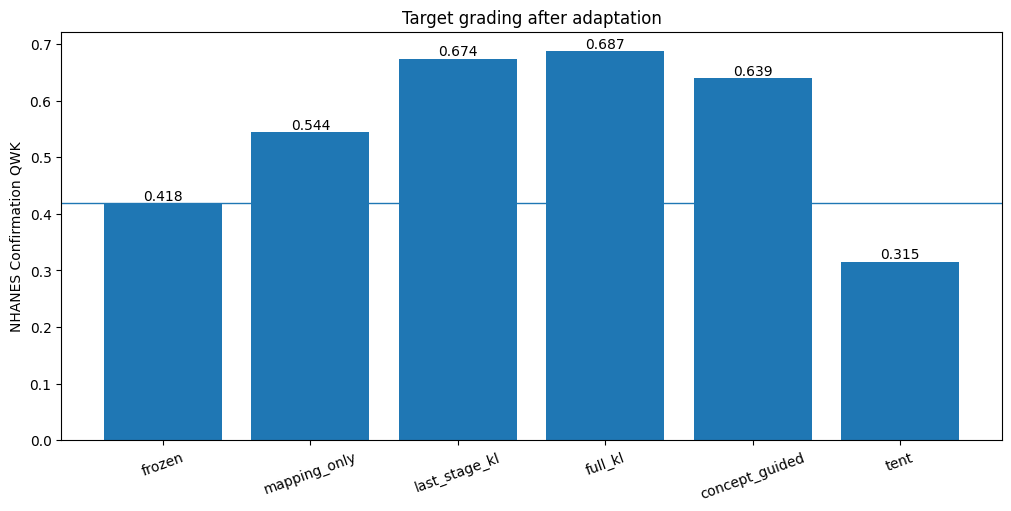

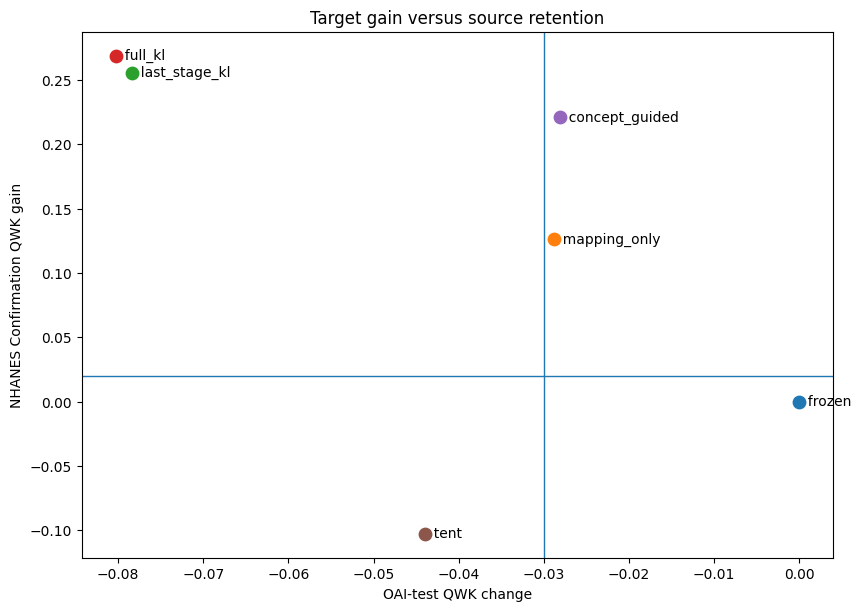

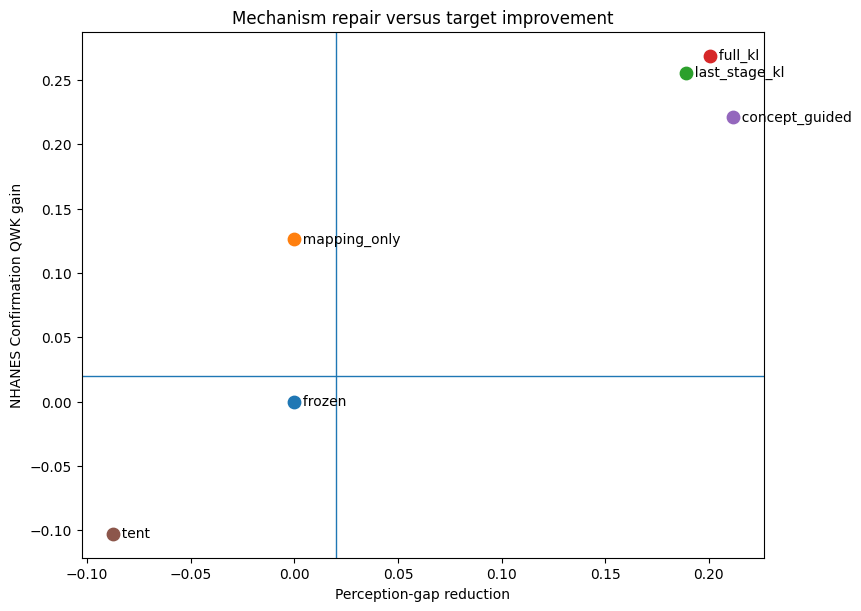

In [14]:



plot_table = (

    TRADEOFF_TABLE

    .set_index("method")

    .loc[list(METHODS)]

)



figure, axis = plt.subplots(

    figsize=(10.0, 5.0),

    constrained_layout=True,

)

bars = axis.bar(

    list(METHODS),

    plot_table[

        "nhanes_confirmation_qwk"

    ].to_numpy(dtype=float),

)

axis.axhline(

    frozen_target_qwk,

    linewidth=1,

)

axis.set_ylabel(

    "NHANES Confirmation QWK"

)

axis.set_title(

    "Target grading after adaptation"

)

axis.tick_params(

    axis="x",

    rotation=20,

)

for bar in bars:

    value = bar.get_height()

    axis.text(

        bar.get_x() + bar.get_width() / 2,

        value,

        f"{value:.3f}",

        ha="center",

        va="bottom",

    )

save_figure(

    figure,

    "F01_target_performance",

)





figure, axis = plt.subplots(

    figsize=(8.5, 6.0),

    constrained_layout=True,

)

for method in METHODS:

    row = plot_table.loc[method]

    axis.scatter(

        row["oai_qwk_change"],

        row["target_qwk_gain"],

        s=80,

    )

    axis.text(

        row["oai_qwk_change"],

        row["target_qwk_gain"],

        f"  {method}",

        va="center",

    )

axis.axvline(

    -CONFIG.source_loss_margin,

    linewidth=1,

)

axis.axhline(

    CONFIG.target_gain_margin,

    linewidth=1,

)

axis.set_xlabel(

    "OAI-test QWK change"

)

axis.set_ylabel(

    "NHANES Confirmation QWK gain"

)

axis.set_title(

    "Target gain versus source retention"

)

save_figure(

    figure,

    "F02_target_source_tradeoff",

)





figure, axis = plt.subplots(

    figsize=(8.5, 6.0),

    constrained_layout=True,

)

for method in METHODS:

    row = plot_table.loc[method]

    axis.scatter(

        row["perception_gap_reduction"],

        row["target_qwk_gain"],

        s=80,

    )

    axis.text(

        row["perception_gap_reduction"],

        row["target_qwk_gain"],

        f"  {method}",

        va="center",

    )

axis.axvline(

    CONFIG.gap_reduction_margin,

    linewidth=1,

)

axis.axhline(

    CONFIG.target_gain_margin,

    linewidth=1,

)

axis.set_xlabel(

    "Perception-gap reduction"

)

axis.set_ylabel(

    "NHANES Confirmation QWK gain"

)

axis.set_title(

    "Mechanism repair versus target improvement"

)

save_figure(

    figure,

    "F03_mechanism_target_tradeoff",

)


## 11. Final audit and certificate


In [15]:



required_files = [

    RESULT_DIR / "training_history.csv",

    RESULT_DIR / "scientific_verdict.json",

    TABLE_DIR / "T01_cohort_summary.csv",

    TABLE_DIR / "T02_image_path_audit.csv",

    TABLE_DIR / "T03_checkpoint_gate.csv",

    TABLE_DIR / "T04_method_metrics.csv",

    TABLE_DIR / "T05_perception_gap.csv",

    TABLE_DIR / "T06_bootstrap_draws.csv",

    TABLE_DIR / "T07_bootstrap_intervals.csv",

    TABLE_DIR / "T08_tradeoff_table.csv",

    MANIFEST_DIR / "discovery_split.csv",

    MANIFEST_DIR / "checkpoint_manifest.csv",

    FIGURE_DIR / "F01_target_performance.png",

    FIGURE_DIR / "F01_target_performance.pdf",

    FIGURE_DIR / "F02_target_source_tradeoff.png",

    FIGURE_DIR / "F02_target_source_tradeoff.pdf",

    FIGURE_DIR / "F03_mechanism_target_tradeoff.png",

    FIGURE_DIR / "F03_mechanism_target_tradeoff.pdf",

]



audit_rows = []



for path in required_files:

    exists = path.exists()

    nonempty = (

        exists

        and path.stat().st_size > 0

    )

    fresh = (

        nonempty

        and path.stat().st_mtime

        >= RUN_STARTED_TIMESTAMP - 1.0

    )



    audit_rows.append({

        "file": path.name,

        "path": str(path),

        "exists": exists,

        "nonempty": nonempty,

        "fresh": fresh,

        "size_bytes": (

            int(path.stat().st_size)

            if exists

            else None

        ),

        "sha256": (

            sha256_file(path)

            if nonempty

            else None

        ),

    })



drive_audit = pd.DataFrame(audit_rows)



criteria = {

    "N03 passed":

        bool(N03_STATUS.get("passed", False)),



    "N04 passed":

        bool(N04_STATUS.get("passed", False)),



    "Discovery train and validation are patient-disjoint":

        not bool(train_patients & validation_patients),



    "Confirmation excluded from adaptation and selection":

        not bool(

            set(NHANES_CONFIRMATION["patient_id"])

            & set(NHANES_DISCOVERY["patient_id"])

        ),



    "three checkpoints completed for each trainable method":

        all(

            len([

                record

                for record in TRAINED_RECORDS

                if record["method"] == method

            ]) == 3

            for method in TRAINABLE_METHODS

        ),



    "all six methods evaluated":

        set(METHOD_METRICS["method"]) == set(METHODS),



    "all methods evaluated on all three subsets":

        len(METHOD_METRICS)

        == len(METHODS) * len(EVALUATION_SETS),



    "participant bootstrap completed":

        len(BOOTSTRAP_DRAWS)

        == CONFIG.bootstrap_repetitions,



    "at least 99 percent of bootstrap draws are valid":

        bool(

            (

                BOOTSTRAP_INTERVALS["valid_draws"]

                >= int(

                    0.99

                    * CONFIG.bootstrap_repetitions

                )

            ).all()

        ),



    "neutral trade-off verdict produced":

        overall_verdict in {

            "one_or_more_methods_pass_all_tradeoffs",

            "no_method_dominates_all_tradeoffs",

        },



    "all required artifacts exist":

        bool(drive_audit["nonempty"].all()),



    "all required artifacts are fresh":

        bool(drive_audit["fresh"].all()),



    "all output paths use Final Pipeline":

        bool(

            drive_audit["path"]

            .str.startswith(str(FINAL_ROOT))

            .all()

        ),

}



criteria_table = pd.DataFrame([

    {

        "criterion": name,

        "passed": bool(value),

    }

    for name, value in criteria.items()

])



passed = bool(criteria_table["passed"].all())



atomic_csv(

    drive_audit,

    RESULT_DIR / "drive_save_audit.csv",

)

atomic_csv(

    criteria_table,

    RESULT_DIR / "acceptance_criteria.csv",

)



status = {

    "stage": "N05",

    "protocol": PROTOCOL,

    "passed": passed,

    "overall_verdict": overall_verdict,

    "methods_passing_all": passing_methods,

    "best_target_method": best_target_method,

    "best_gap_repair_method": best_gap_method,

    "best_source_retention_method": best_source_method,

    "created_utc":

        datetime.now(timezone.utc).isoformat(),

}

atomic_json(

    status,

    RESULT_DIR / "status.json",

)



manifest_rows = []



for path in required_files:

    if path.exists() and path.stat().st_size > 0:

        manifest_rows.append({

            "path": str(

                path.relative_to(FINAL_ROOT)

            ),

            "size_bytes": int(

                path.stat().st_size

            ),

            "sha256": sha256_file(path),

            "generator": NOTEBOOK_NAME,

            "protocol": PROTOCOL,

        })



atomic_csv(

    pd.DataFrame(manifest_rows),

    MANIFEST_DIR / "output_manifest.csv",

)



certificate_lines = [

    "=" * 78,

    "N05 ADAPTATION STRATEGIES CERTIFICATE",

    "=" * 78,

]



for row in criteria_table.itertuples(index=False):

    certificate_lines.append(

        ("PASS  " if row.passed else "FAIL  ")

        + str(row.criterion)

    )



certificate_lines.extend([

    "",

    f"Overall verdict: {overall_verdict}",

    f"Methods passing all trade-offs: {passing_methods}",

    f"Best target method: {best_target_method}",

    f"Best gap-repair method: {best_gap_method}",

    f"Best source-retention method: {best_source_method}",

    (

        "FINAL STATUS: PASS"

        if passed

        else "FINAL STATUS: FAIL"

    ),

    (

        "PIPELINE COMPLETE: YES"

        if passed

        else "PIPELINE COMPLETE: NO"

    ),

    "=" * 78,

])



certificate = "\n".join(certificate_lines)



(

    RESULT_DIR / "certificate.txt"

).write_text(

    certificate,

    encoding="utf-8",

)



display(TRADEOFF_TABLE.round(4))

display(BOOTSTRAP_INTERVALS.round(4))

display(criteria_table)



print()

print(certificate)



if not passed:

    raise RuntimeError(

        "N05 final audit failed."

    )


,method,nhanes_confirmation_qwk,target_qwk_gain,perception_gap,perception_gap_reduction,oai_test_qwk,oai_qwk_change,shared_concept_qwk,osteophyte_grade_2_recall,concept_entropy_aurc,passes_target_gain,passes_gap_reduction,passes_source_retention,passes_all
0,frozen,0.4182,0.0000,0.5104,0.0000,0.7470,0.0000,0.3855,0.0500,0.3880,False,False,True,False
1,mapping_only,0.5444,0.1262,0.5104,0.0000,0.7182,-0.0288,0.3855,0.0500,0.3079,True,False,True,False
2,last_stage_kl,0.6741,0.2558,0.3216,0.1887,0.6687,-0.0784,0.5879,0.0786,0.2228,True,True,False,False
3,full_kl,0.6872,0.2690,0.3097,0.2006,0.6667,-0.0803,0.6076,0.0357,0.2152,True,True,False,False
4,concept_guided,0.6393,0.2211,0.2988,0.2115,0.7189,-0.0281,0.6553,0.5357,0.2508,True,True,True,True
5,tent,0.3154,-0.1029,0.5980,-0.0876,0.7030,-0.0440,0.3084,0.0286,0.4866,False,False,False,False


,method,endpoint,estimate,ci_lower,ci_upper,valid_draws
0,frozen,qwk_gain,0.0000,0.0000,0.0000,2000
1,frozen,gap_reduction,-0.0002,-0.0364,0.0351,2000
2,mapping_only,qwk_gain,0.1260,0.1031,0.1496,2000
3,mapping_only,gap_reduction,-0.0002,-0.0364,0.0351,2000
4,last_stage_kl,qwk_gain,0.2551,0.2155,0.2962,2000
5,last_stage_kl,gap_reduction,0.1886,0.1528,0.2233,2000
6,full_kl,qwk_gain,0.2685,0.2288,0.3086,2000
7,full_kl,gap_reduction,0.2006,0.1653,0.2344,2000
8,concept_guided,qwk_gain,0.2205,0.1853,0.2555,2000
9,concept_guided,gap_reduction,0.2111,0.1732,0.2462,2000


,criterion,passed
0,N03 passed,True
1,N04 passed,True
2,Discovery train and validation are patient-dis...,True
3,Confirmation excluded from adaptation and sele...,True
4,three checkpoints completed for each trainable...,True
5,all six methods evaluated,True
6,all methods evaluated on all three subsets,True
7,participant bootstrap completed,True
8,at least 99 percent of bootstrap draws are valid,True
9,neutral trade-off verdict produced,True



N05 ADAPTATION STRATEGIES CERTIFICATE
PASS  N03 passed
PASS  N04 passed
PASS  Discovery train and validation are patient-disjoint
PASS  Confirmation excluded from adaptation and selection
PASS  three checkpoints completed for each trainable method
PASS  all six methods evaluated
PASS  all methods evaluated on all three subsets
PASS  participant bootstrap completed
PASS  at least 99 percent of bootstrap draws are valid
PASS  neutral trade-off verdict produced
PASS  all required artifacts exist
PASS  all required artifacts are fresh
PASS  all output paths use Final Pipeline

Overall verdict: one_or_more_methods_pass_all_tradeoffs
Methods passing all trade-offs: ['concept_guided']
Best target method: full_kl
Best gap-repair method: concept_guided
Best source-retention method: frozen
FINAL STATUS: PASS
PIPELINE COMPLETE: YES
